## Loading Packages 

In [1]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder


import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper

import torch
import torchtuples as tt


from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

import pandas as pd
from IPython.display import display

from sklearn.preprocessing import StandardScaler


from pycox.models import DeepHitSingle


import numpy as np
import pandas as pd
import torch
import torchtuples as tt
from sklearn_pandas import DataFrameMapper
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pycox.models import CoxPH
from pycox.models.loss import CoxPHLoss
from pycox.evaluation import EvalSurv
import time

/home/justine/miniconda3/envs/py37/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Cleaning

In [4]:

malawi_file_path = './nfm/data/Malawi_cleanednew.csv'
zambia_file_path ='./nfm/data/Zambia_cleanednew.csv'
SA_file_path = './nfm/data/SouthAfrica_cleanednew.csv'
zimbabwe_file_path = './nfm/data/Zimbabwe_cleanednew.csv'



zimbabwe_df = pd.read_csv(zimbabwe_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')
malawi_df = pd.read_csv(malawi_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')
zambia_df = pd.read_csv(zambia_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')
sa_df = pd.read_csv(SA_file_path, encoding='ISO-8859-1').drop(columns=['MIDX', 'V001','CASEID'], errors='ignore')  # Adjust encoding as needed


print("Zimbabwe Data:")
display(zimbabwe_df.head())

print("\nMalawi Data:")
display(malawi_df.head())

print("\nZambia Data:")
display(zambia_df.head())

print("\nSouth Africa Data:")
display(sa_df.head())


Zimbabwe Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,57.034908,0,1,2,0,2,3,1,0,0,...,1,1,0,2,1,1,4,0,2,1
1,39.819302,0,0,2,0,2,3,1,0,1,...,1,1,0,2,2,1,4,0,1,1
2,4.008214,0,0,1,0,2,2,2,1,0,...,1,1,0,2,3,1,4,1,1,1
3,26.151951,0,1,2,0,2,3,1,0,0,...,1,1,0,2,2,0,4,0,2,1
4,44.616016,0,0,2,0,2,3,1,0,0,...,1,1,0,2,1,0,4,0,2,1



Malawi Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,59.301848,0,0,2,1,0,2,1,1,0,...,1,0,1,2,1,0,3,0,1,1
1,22.439425,0,1,2,0,0,3,1,1,0,...,1,0,1,2,1,1,4,0,2,1
2,44.418891,0,1,1,0,0,2,1,0,0,...,1,0,1,2,1,0,4,0,1,1
3,57.724846,0,0,2,0,0,2,1,0,0,...,1,0,0,2,0,1,2,0,1,0
4,20.501027,0,1,1,1,0,1,1,1,0,...,1,0,1,2,1,1,3,0,1,1



Zambia Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,10.973306,0,1,2,0,1,4,1,1,0,...,1,0,0,2,1,1,4,1,2,1
1,13.273101,0,1,0,0,1,1,1,1,0,...,1,1,0,2,1,1,3,0,1,1
2,22.735113,0,1,1,1,1,2,2,0,1,...,1,0,0,2,1,1,4,0,1,1
3,4.271047,0,1,1,0,1,2,2,1,0,...,1,1,0,2,2,1,4,1,2,1
4,28.977413,0,0,3,0,1,3,1,0,0,...,1,0,0,2,1,1,4,0,1,1



South Africa Data:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,53.979466,0,0,3,1,0,2,2,0,0,...,3,1,0,1,2,0,4,0,1,1
1,51.318275,0,1,1,1,0,1,1,0,1,...,3,0,0,1,0,1,2,0,1,1
2,44.123203,0,1,1,0,0,1,1,0,0,...,3,1,0,1,0,0,2,0,1,1
3,29.864476,0,0,1,0,0,2,1,0,0,...,3,1,0,1,2,0,4,0,1,0
4,5.782341,0,1,0,0,0,1,1,1,0,...,3,0,0,1,1,0,4,1,1,0


In [5]:

def get_dataset_info(df):
    info = pd.DataFrame({
        'Variable Name': df.columns,
        'Variable Type': df.dtypes,
        'Percentage Missing': df.isnull().mean() * 100
    })
    return info

In [6]:

zimbabwe_info = get_dataset_info(zimbabwe_df)
malawi_info = get_dataset_info(malawi_df)
zambia_info = get_dataset_info(zambia_df)
sa_info = get_dataset_info(sa_df)


print("Zimbabwe Dataset Info:")
display(zimbabwe_info)

print("\nMalawi Dataset Info:")
display(malawi_info)

print("\nZambia Dataset Info:")
display(zambia_info)

print("\nSouth Africa Dataset Info:")
display(sa_info)

Zimbabwe Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0



Malawi Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0



Zambia Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0



South Africa Dataset Info:


,Variable Name,Variable Type,Percentage Missing
survival_time,survival_time,float64,0.0
Status,Status,int64,0.0
B4,B4,int64,0.0
age_group,age_group,int64,0.0
age_first_birth,age_first_birth,int64,0.0
drinking_water_source,drinking_water_source,int64,0.0
BORD_recoded,BORD_recoded,int64,0.0
V208_recoded,V208_recoded,int64,0.0
V404,V404,int64,0.0
V213,V213,int64,0.0


In [7]:
zimbabwe_df.shape

(4436, 26)

In [8]:


def convert_to_categorical(df, exclude_columns):
    for column in df.columns:
        if column not in exclude_columns:
            df[column] = df[column].astype('category')
    return df

exclude_columns = ['CASEID', 'Unnamed: 0', 'survival_time']


zimbabwe_df = convert_to_categorical(zimbabwe_df, exclude_columns)
malawi_df = convert_to_categorical(malawi_df, exclude_columns)
zambia_df = convert_to_categorical(zambia_df, exclude_columns)
sa_df = convert_to_categorical(sa_df, exclude_columns)



In [9]:

def delete_columns(df, columns_to_delete):
    df = df.drop(columns=columns_to_delete, errors='ignore')
    return df

columns_to_delete = ['CASEID']


zimbabwe_df = delete_columns(zimbabwe_df, columns_to_delete)
malawi_df = delete_columns(malawi_df, columns_to_delete)
zambia_df = delete_columns(zambia_df, columns_to_delete)
sa_df = delete_columns(sa_df, columns_to_delete)


print("\nZimbabwe Data After Deleting Columns:")
display(zimbabwe_df.head())

print("\nMalawi Data After Deleting Columns:")
display(malawi_df.head())

print("\nZambia Data After Deleting Columns:")
display(zambia_df.head())

print("\nSouth Africa Data After Deleting Columns:")
display(sa_df.head())



Zimbabwe Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,57.034908,0,1,2,0,2,3,1,0,0,...,1,1,0,2,1,1,4,0,2,1
1,39.819302,0,0,2,0,2,3,1,0,1,...,1,1,0,2,2,1,4,0,1,1
2,4.008214,0,0,1,0,2,2,2,1,0,...,1,1,0,2,3,1,4,1,1,1
3,26.151951,0,1,2,0,2,3,1,0,0,...,1,1,0,2,2,0,4,0,2,1
4,44.616016,0,0,2,0,2,3,1,0,0,...,1,1,0,2,1,0,4,0,2,1



Malawi Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,59.301848,0,0,2,1,0,2,1,1,0,...,1,0,1,2,1,0,3,0,1,1
1,22.439425,0,1,2,0,0,3,1,1,0,...,1,0,1,2,1,1,4,0,2,1
2,44.418891,0,1,1,0,0,2,1,0,0,...,1,0,1,2,1,0,4,0,1,1
3,57.724846,0,0,2,0,0,2,1,0,0,...,1,0,0,2,0,1,2,0,1,0
4,20.501027,0,1,1,1,0,1,1,1,0,...,1,0,1,2,1,1,3,0,1,1



Zambia Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,10.973306,0,1,2,0,1,4,1,1,0,...,1,0,0,2,1,1,4,1,2,1
1,13.273101,0,1,0,0,1,1,1,1,0,...,1,1,0,2,1,1,3,0,1,1
2,22.735113,0,1,1,1,1,2,2,0,1,...,1,0,0,2,1,1,4,0,1,1
3,4.271047,0,1,1,0,1,2,2,1,0,...,1,1,0,2,2,1,4,1,2,1
4,28.977413,0,0,3,0,1,3,1,0,0,...,1,0,0,2,1,1,4,0,1,1



South Africa Data After Deleting Columns:


,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,V208_recoded,V404,V213,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,53.979466,0,0,3,1,0,2,2,0,0,...,3,1,0,1,2,0,4,0,1,1
1,51.318275,0,1,1,1,0,1,1,0,1,...,3,0,0,1,0,1,2,0,1,1
2,44.123203,0,1,1,0,0,1,1,0,0,...,3,1,0,1,0,0,2,0,1,1
3,29.864476,0,0,1,0,0,2,1,0,0,...,3,1,0,1,2,0,4,0,1,0
4,5.782341,0,1,0,0,0,1,1,1,0,...,3,0,0,1,1,0,4,1,1,0


In [10]:
zimbabwe_df.shape

(4436, 26)

In [11]:

categorical_vars = ['B4','age_group', 'age_first_birth', 'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode', 'V130_recode', 'M70_recode', 'M3A', 'V161_recode','V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']

zambia_sa_categorical_vars = categorical_vars 

def convert_variable_types(df, categorical_vars, float_vars):
    for column in df.columns:
        if column in categorical_vars:
            df[column] = df[column].astype('category')
        elif column in float_vars:
            df[column] = df[column].astype('float')
    return df

float_vars = ['survival_time', 'survival_time_standardized']

zimbabwe_df = convert_variable_types(zimbabwe_df, categorical_vars, float_vars)
malawi_df = convert_variable_types(malawi_df, categorical_vars, float_vars)
zambia_df = convert_variable_types(zambia_df, zambia_sa_categorical_vars, float_vars)
sa_df = convert_variable_types(sa_df, zambia_sa_categorical_vars, float_vars)




In [12]:

zimbabwe_df.shape

(4436, 26)

In [13]:
malawi_df.shape


(12671, 26)

In [14]:
zambia_df.shape


(6730, 26)

In [15]:
sa_df.shape

(2760, 26)

In [16]:

def create_selected_dataset(df, selected_vars, duration_col, event_col):
    
    selected_vars_with_outcome = selected_vars + [duration_col, event_col]
    
    new_df = df[selected_vars_with_outcome].copy()
    return new_df

selected_vars_zimbabwe = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']
selected_vars_malawi = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']
selected_vars_zambia = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']
selected_vars_sa = ['B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']


zimbabwe_selected_df = create_selected_dataset(zimbabwe_df, selected_vars_zimbabwe, 'survival_time', 'Status')
malawi_selected_df = create_selected_dataset(malawi_df, selected_vars_malawi, 'survival_time', 'Status')
zambia_selected_df = create_selected_dataset(zambia_df, selected_vars_zambia, 'survival_time', 'Status')
sa_selected_df = create_selected_dataset(sa_df, selected_vars_sa, 'survival_time', 'Status')




In [17]:
zimbabwe_selected_df.shape

(4436, 26)

In [18]:
malawi_selected_df.shape

(12671, 26)

In [19]:
zambia_selected_df.shape

(6730, 26)

In [21]:
sa_selected_df.shape

(2760, 26)

In [22]:

zimbabwe_selected_df = pd.get_dummies(zimbabwe_selected_df, drop_first=True)
malawi_selected_df = pd.get_dummies(malawi_selected_df, drop_first=True)
zambia_selected_df = pd.get_dummies(zambia_selected_df, drop_first=True)
sa_selected_df = pd.get_dummies(sa_selected_df, drop_first=True)


In [23]:
zimbabwe_selected_df.shape

(4436, 54)

In [24]:
malawi_selected_df.shape

(12671, 52)

In [25]:
zambia_selected_df.shape

(6730, 54)

In [27]:
sa_selected_df.shape

(2760, 53)

In [28]:
# Drop missing values or handle them appropriately
zimbabwe_selected_df = zimbabwe_selected_df.dropna()
malawi_selected_df = malawi_selected_df.dropna()
zambia_selected_df = zambia_selected_df.dropna()
sa_selected_df = sa_selected_df.dropna()


In [29]:
zimbabwe_selected_df.shape

(4436, 54)

In [30]:
malawi_selected_df.shape

(12671, 52)

In [31]:
zambia_selected_df.shape

(6730, 54)

In [32]:
sa_selected_df.shape

(2760, 53)

In [33]:
# Display the column names of your dataframe
print(zimbabwe_selected_df.columns)
print(malawi_selected_df.columns)
print(zambia_selected_df.columns)
print(sa_selected_df.columns)


Index(['survival_time', 'B4_1', 'age_group_1', 'age_group_2', 'age_group_3',
       'age_first_birth_1', 'age_first_birth_2', 'drinking_water_source_1',
       'drinking_water_source_2', 'drinking_water_source_3',
       'drinking_water_source_4', 'BORD_recoded_2', 'BORD_recoded_3',
       'BORD_recoded_4', 'V208_recoded_2', 'V208_recoded_3', 'V208_recoded_4',
       'V404_1', 'V213_1', 'V405_1', 'V218_recoded_1', 'V218_recoded_2',
       'V218_recoded_3', 'V218_recoded_4', 'V502_1', 'V502_2', 'V190_1',
       'V190_2', 'V190_3', 'V190_4', 'V201_recoded_2', 'V201_recoded_3',
       'V201_recoded_4', 'V605_recode_1', 'V605_recode_3', 'V130_recode_3',
       'M70_recode_1', 'M3A_1', 'V161_recode_1', 'V161_recode_2',
       'V161_recode_3', 'V137_recode_1', 'V137_recode_2', 'V137_recode_3',
       'V137_recode_4+', 'V716_working_1', 'V136_recode_2', 'V136_recode_3',
       'V136_recode_4', 'V209_recode_1', 'M18_recode_1', 'M18_recode_2',
       'V151_1', 'Status_1'],
      dtype='object')

In [34]:
zimbabwe_selected_df.to_csv('zimbabwe_selected_df.csv', index=False)
malawi_selected_df.to_csv('malawi_selected_df.csv', index=False)
zambia_selected_df.to_csv('zambia_selected_df.csv', index=False)
sa_selected_df.to_csv('sa_selected_df.csv', index=False)

## DeepSurv Model

In [35]:


import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from sklearn.model_selection import KFold
import numpy as np
from sklearn.metrics import brier_score_loss

class SimpleMLP(nn.Module):
    def __init__(self, in_features):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(in_features, 120)
        self.fc2 = nn.Linear(120, 120)
        self.out = nn.Linear(120, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.float()  
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.out(x)


def calculate_brier_score(surv, durations, events, time_point):
    
    closest_time = surv.index.values[np.argmin(np.abs(surv.index.values - time_point))]
    surv_at_time = surv.loc[closest_time].values
    brier = brier_score_loss(events, surv_at_time, pos_label=1)
    return brier

def fit_pycox_model_cv(df, duration_col, event_col, dataset_name, model_type='deepsurv', folds=5, epochs=100, lr=0.01, batch_size=64, time_fraction=0.8):
    # Prepare the data
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)  # Convert to float32
    y = (df[duration_col].values, df[event_col].values)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    c_index_results = []
    brier_score_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        if model_type == 'deepsurv':
            net = SimpleMLP(in_features=x_train.shape[1])
            model = CoxPH(net, tt.optim.Adam)

        log = model.fit(x_train, y_train, batch_size, epochs, callbacks=[tt.callbacks.EarlyStopping(patience=10)], val_data=(x_val, y_val), verbose=False)

        model.compute_baseline_hazards()
        surv = model.predict_surv_df(x_val)
        ev = EvalSurv(surv, y_val[0], y_val[1], censor_surv='km')
        c_index = ev.concordance_td('antolini')
        c_index_results.append(c_index)

        time_point = surv.index.values[-1] * time_fraction

        brier_score = calculate_brier_score(surv, y_val[0], y_val[1], time_point)
        brier_score_results.append(brier_score)
        print(f'{dataset_name} - Fold {fold} C-index: {c_index}, Brier score at time {time_point:.2f}: {brier_score}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results) if brier_score_results else None

    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    if mean_brier_score is not None:
        print(f'{dataset_name} - Mean Brier score over {folds} folds at time {time_point:.2f}: {mean_brier_score}\n')

    return model, mean_c_index, mean_brier_score

pycox_model_zimbabwe, mean_c_index_zimbabwe, mean_brier_zimbabwe = fit_pycox_model_cv(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe')
pycox_model_malawi, mean_c_index_malawi, mean_brier_malawi = fit_pycox_model_cv(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi')
pycox_model_zambia, mean_c_index_zambia, mean_brier_zambia = fit_pycox_model_cv(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia')
pycox_model_sa, mean_c_index_sa, mean_brier_sa = fit_pycox_model_cv(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')


Zimbabwe - Fold 1 C-index: 0.3930483244115275, Brier score at time 47.99: 0.949567823474562
Zimbabwe - Fold 2 C-index: 0.42551046130577264, Brier score at time 47.99: 0.9527510640124879
Zimbabwe - Fold 3 C-index: 0.6223277909738717, Brier score at time 47.99: 0.9524382126361448
Zimbabwe - Fold 4 C-index: 0.46616198467712516, Brier score at time 47.99: 0.9518427363623309
Zimbabwe - Fold 5 C-index: 0.5254858819215255, Brier score at time 47.99: 0.9543187913743402
Zimbabwe - Mean C-index over 5 folds: 0.48650688865796454
Zimbabwe - Mean Brier score over 5 folds at time 47.99: 0.9521837255719732

Malawi - Fold 1 C-index: 0.4424596185779701, Brier score at time 47.99: 0.9437578086740945
Malawi - Fold 2 C-index: 0.36170127368083055, Brier score at time 47.99: 0.9439830288903893
Malawi - Fold 3 C-index: 0.4330064411303894, Brier score at time 47.99: 0.9481722543129542
Malawi - Fold 4 C-index: 0.3550848833643039, Brier score at time 47.99: 0.9459648442073708
Malawi - Fold 5 C-index: 0.60396517

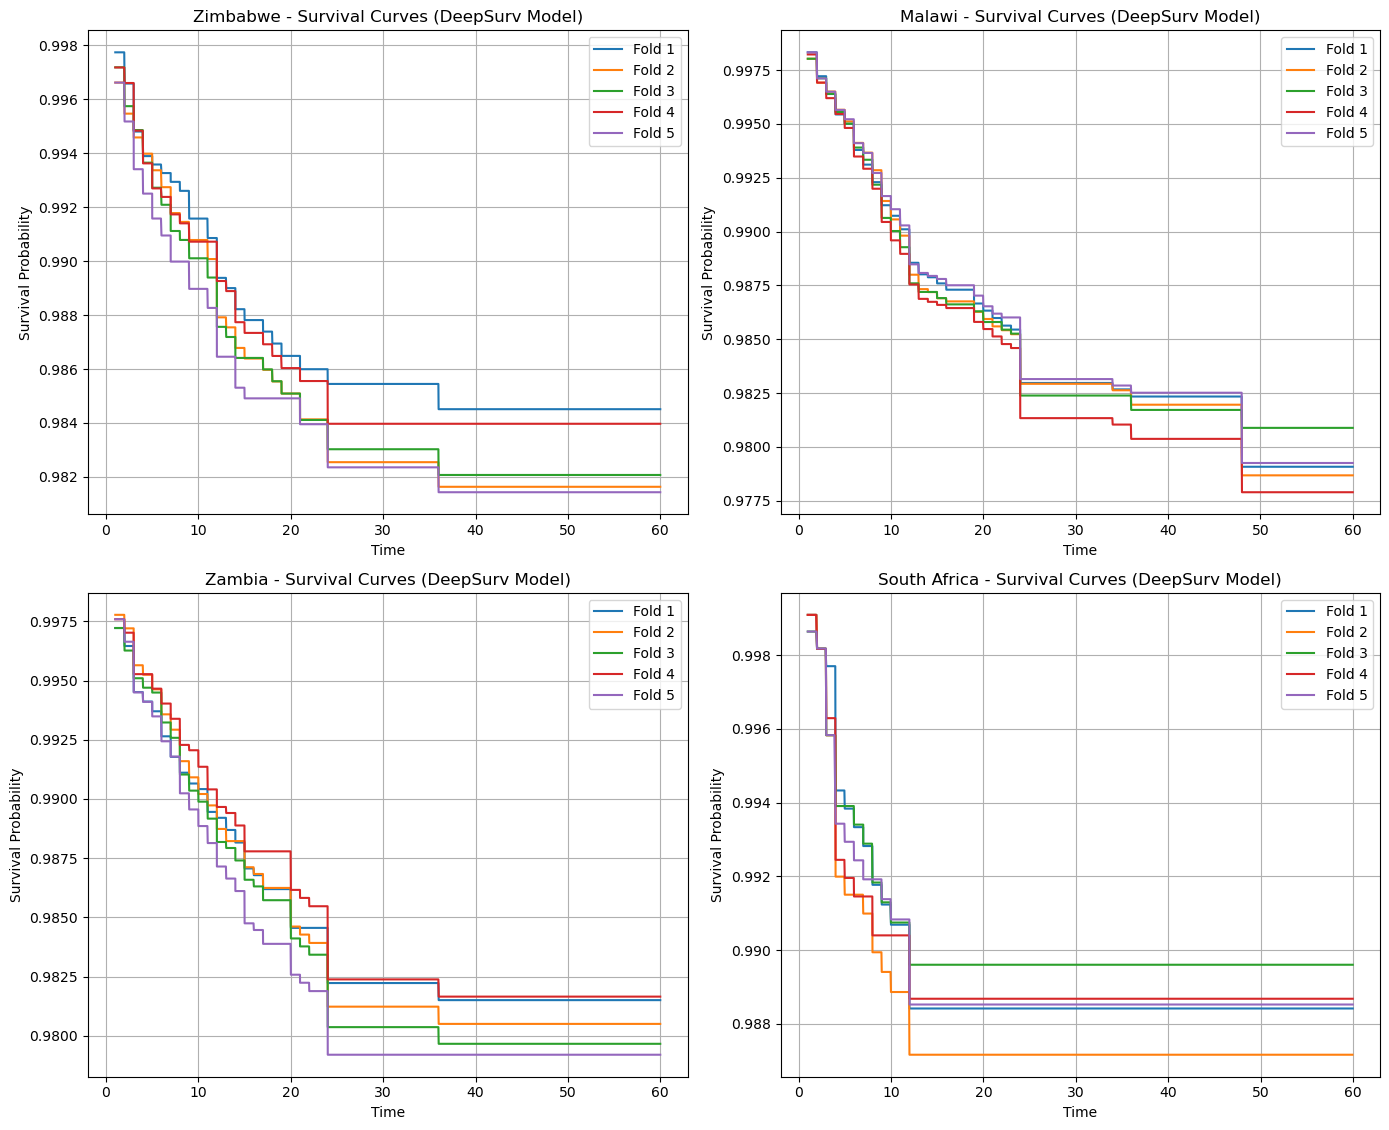

In [36]:
import matplotlib.pyplot as plt
import os

def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    """
    Plot the mean survival curves for each country in a 2x2 grid.
    
    Parameters:
    - mean_survival_curves_dict: A dictionary where keys are country names and values are lists of survival curves for each fold.
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    axs = axs.flatten()

    for i, (country, survival_curves) in enumerate(mean_survival_curves_dict.items()):
        for fold_idx, surv in enumerate(survival_curves):
            mean_surv = surv.mean(axis=1)
            axs[i].plot(surv.index, mean_surv, label=f'Fold {fold_idx + 1}')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Survival Probability')
        axs[i].set_title(f'{country} - Survival Curves (DeepSurv Model)')
        axs[i].grid(True)
        axs[i].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plots_folder = "Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_path = os.path.join(plots_folder, f'Mean_Survival_Curves_DeepSurv.png')
    plt.savefig(plot_path)
    plt.show()

def fit_and_collect_survival_curves(df, duration_col, event_col, dataset_name, model_type='deepsurv', folds=5, epochs=100, lr=0.01, batch_size=64):
    
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)  # Convert to float32
    y = (df[duration_col].values, df[event_col].values)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        if model_type == 'deepsurv':
            net = SimpleMLP(in_features=x_train.shape[1])
            model = CoxPH(net, tt.optim.Adam)

        log = model.fit(x_train, y_train, batch_size, epochs, callbacks=[tt.callbacks.EarlyStopping(patience=10)], val_data=(x_val, y_val), verbose=False)

        model.compute_baseline_hazards()


        surv = model.predict_surv_df(x_val)
        mean_survival_curves.append(surv)

    return mean_survival_curves


mean_survival_curves_dict = {
    'Zimbabwe': fit_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_for_countries(mean_survival_curves_dict)


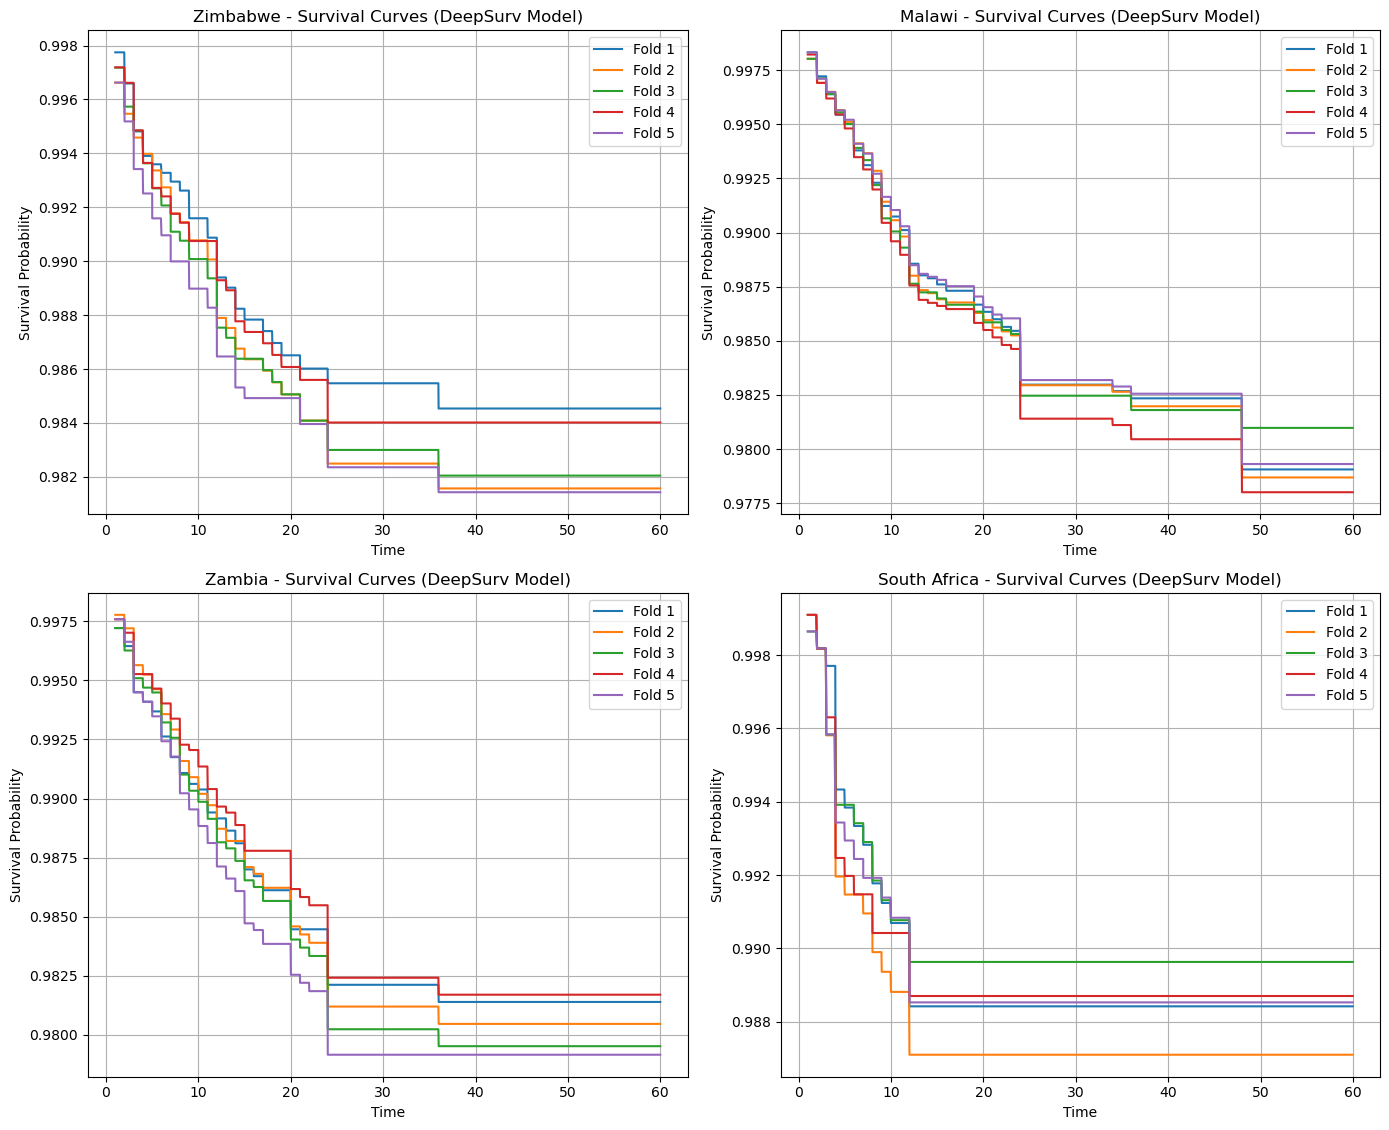

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import KFold
import torch
import torchtuples as tt
from pycox.models import CoxPH

class SimpleMLP(torch.nn.Module):
    def __init__(self, in_features, num_nodes=256, out_features=1):
        super(SimpleMLP, self).__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_features, num_nodes),
            torch.nn.ReLU(),
            torch.nn.Linear(num_nodes, num_nodes),
            torch.nn.ReLU(),
            torch.nn.Linear(num_nodes, out_features)
        )

    def forward(self, x):
        return self.net(x)

def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    """
    Plot the mean survival curves for each country in a 2x2 grid.
    
    Parameters:
    - mean_survival_curves_dict: A dictionary where keys are country names and values are lists of survival curves for each fold.
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    axs = axs.flatten()

    for i, (country, survival_curves) in enumerate(mean_survival_curves_dict.items()):
        for fold_idx, surv in enumerate(survival_curves):
            mean_surv = surv.mean(axis=1)  
            axs[i].plot(surv.index, mean_surv, label=f'Fold {fold_idx + 1}')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Survival Probability')
        axs[i].set_title(f'{country} - Survival Curves (DeepSurv Model)')
        axs[i].grid(True)
        axs[i].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plots_folder = "Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_path = os.path.join(plots_folder, f'Mean_Survival_Curves_DeepSurv.png')
    plt.savefig(plot_path)
    plt.show()

def fit_and_collect_survival_curves(df, duration_col, event_col, dataset_name, model_type='deepsurv', folds=5, epochs=100, lr=0.01, batch_size=64):
    """
    Fit a DeepSurv model and collect survival curves from cross-validation folds.
    """
    
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)  # Convert to float32
    y = (df[duration_col].values, df[event_col].values)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        if model_type == 'deepsurv':
            net = SimpleMLP(in_features=x_train.shape[1])
            model = CoxPH(net, tt.optim.Adam)

        log = model.fit(x_train, y_train, batch_size, epochs, callbacks=[tt.callbacks.EarlyStopping(patience=10)], val_data=(x_val, y_val), verbose=False)

        model.compute_baseline_hazards()

        surv = model.predict_surv_df(x_val)
        mean_survival_curves.append(surv)

    return mean_survival_curves


mean_survival_curves_dict = {
    'Zimbabwe': fit_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}


plot_mean_survival_curves_for_countries(mean_survival_curves_dict)



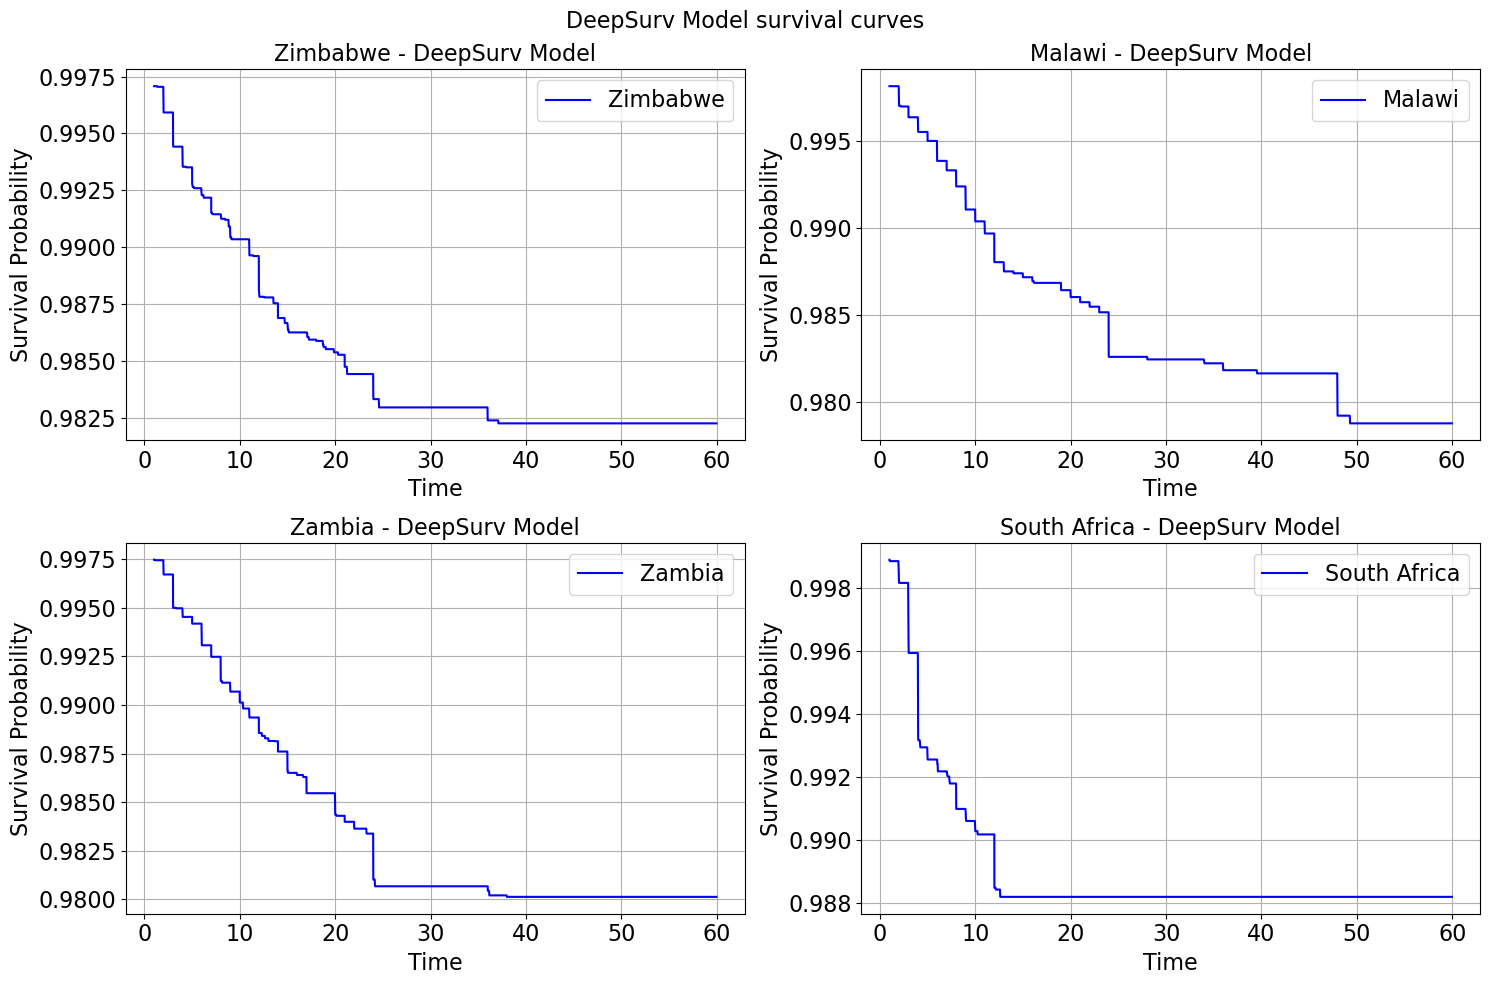

In [38]:

def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))  
    axs = axs.flatten()  

    for i, country in enumerate(countries):
    
        survival_data_list = mean_survival_curves_dict[country]
        
        concatenated_df = pd.concat(survival_data_list, axis=1)
        
        mean_survival_probabilities = concatenated_df.mean(axis=1)
        
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)
        
        time_data = concatenated_df.index.values

        axs[i].plot(time_data, mean_survival_probabilities, label=f'{country}', color='blue')
        axs[i].set_title(f'{country} - DeepSurv Model',fontsize=16)
        axs[i].set_xlabel('Time', fontsize=16)
        axs[i].set_ylabel('Survival Probability', fontsize=16)
        axs[i].legend(fontsize=16)
        axs[i].grid(True)
        axs[i].tick_params(axis="both", labelsize=16)
    fig.suptitle('DeepSurv Model survival curves', fontsize=16)
    plt.tight_layout()
    plt.show()


plot_mean_survival_curves_for_countries(mean_survival_curves_dict)


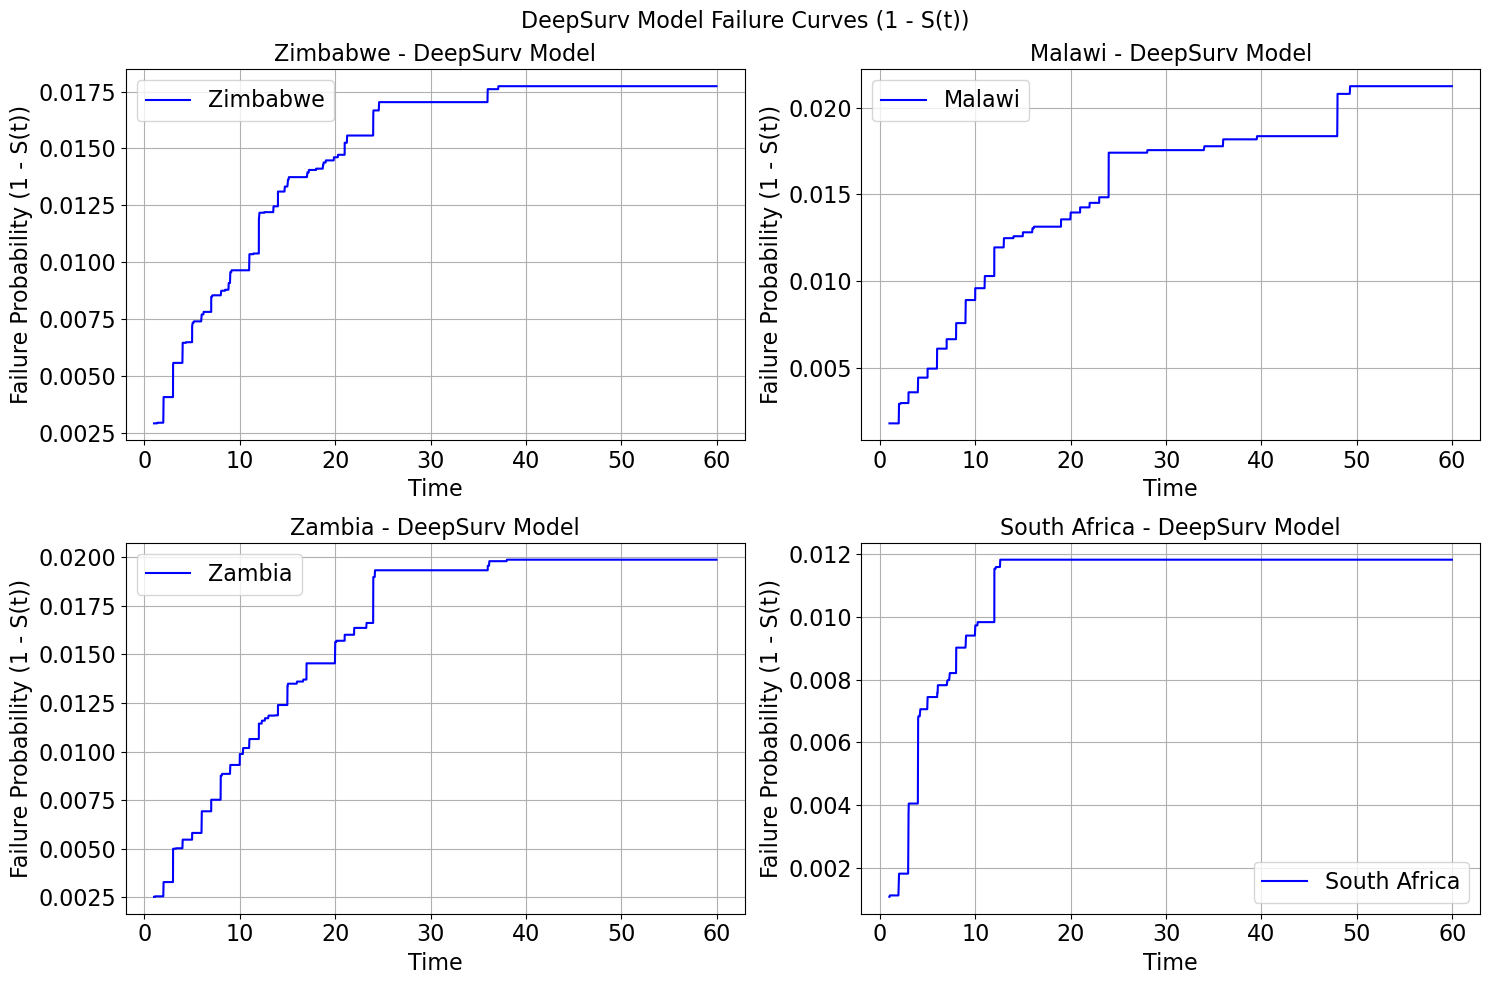

In [39]:
def plot_mean_failure_curves_for_countries(mean_survival_curves_dict):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))  # 2x2 grid
    axs = axs.flatten()

    for i, country in enumerate(countries):
    
        survival_data_list = mean_survival_curves_dict[country]
        
        
        concatenated_df = pd.concat(survival_data_list, axis=1)
        
        
        mean_survival_probabilities = concatenated_df.mean(axis=1)
        
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)
        
    
        failure_probabilities = 1 - mean_survival_probabilities
        
        
        time_data = concatenated_df.index.values

        
        axs[i].plot(time_data, failure_probabilities, label=f'{country}', color='blue')
        axs[i].set_title(f'{country} - DeepSurv Model', fontsize=16)
        axs[i].set_xlabel('Time', fontsize=16)
        axs[i].set_ylabel('Failure Probability (1 - S(t))', fontsize=16)
        axs[i].legend(fontsize=16)
        axs[i].grid(True)
        axs[i].tick_params(axis="both", labelsize=16)

    fig.suptitle('DeepSurv Model Failure Curves (1 - S(t))', fontsize=16)
    plt.tight_layout()
    plt.show()


plot_mean_failure_curves_for_countries(mean_survival_curves_dict)

Low c index poor discrimination


High brier score poor model calibration

High c index outstanding discrimination


High brier score poor model calibration

## DeepHit


In [40]:
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime


class SimpleMLPDeepHit(nn.Module):
    def __init__(self, in_features, num_durations, num_risks=1, num_nodes=[32, 32], dropout=0.1):
        super(SimpleMLPDeepHit, self).__init__()
        layers = []
        input_size = in_features
        for nodes in num_nodes:
            layers.append(nn.Linear(input_size, nodes))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_size = nodes
        layers.append(nn.Linear(input_size, num_durations))
        self.shared_net = nn.Sequential(*layers)
        self.logits = torch.nn.ModuleList([nn.Linear(num_durations, num_durations) for _ in range(num_risks)])

    def forward(self, x):
        h = self.shared_net(x)
        return [logit(h) for logit in self.logits]


def fit_deephit_model_cv(df, duration_col, event_col, dataset_name, folds=5, epochs=20, lr=0.01, batch_size=64):
    
    
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)
    y = (df[duration_col].values, df[event_col].values)

    
    num_durations = 50  
    labtrans = DeepHitSingle.label_transform(num_durations)
    y = labtrans.fit_transform(*y)
    

    assert np.all(np.diff(labtrans.cuts) > 0), "Cuts are not sorted properly."

    
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []

    
    checkpoint_folder = os.path.expanduser("~/Desktop/Model_Checkpoints")
    os.makedirs(checkpoint_folder, exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        net = SimpleMLPDeepHit(in_features=x_train.shape[1], num_durations=num_durations)
        model = DeepHitSingle(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)

    
        best_score = float('inf')
        for epoch in range(epochs):
            log = model.fit(x_train, y_train, batch_size, 1, val_data=(x_val, y_val), verbose=False)
            current_score = log.to_pandas()['val_loss'].values[-1]
            if current_score < best_score:
                best_score = current_score
                checkpoint_path = os.path.join(checkpoint_folder, f'best_model_fold_{fold}_epoch_{epoch + 1}.pt')
                torch.save(model.net.state_dict(), checkpoint_path)

        
        surv = model.interpolate(10).predict_surv_df(x_val)
        mean_survival_curves.append(surv)

    return mean_survival_curves


mean_survival_curves_dict_deephit = {
    'Zimbabwe': fit_deephit_model_cv(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_deephit_model_cv(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_deephit_model_cv(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_deephit_model_cv(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}




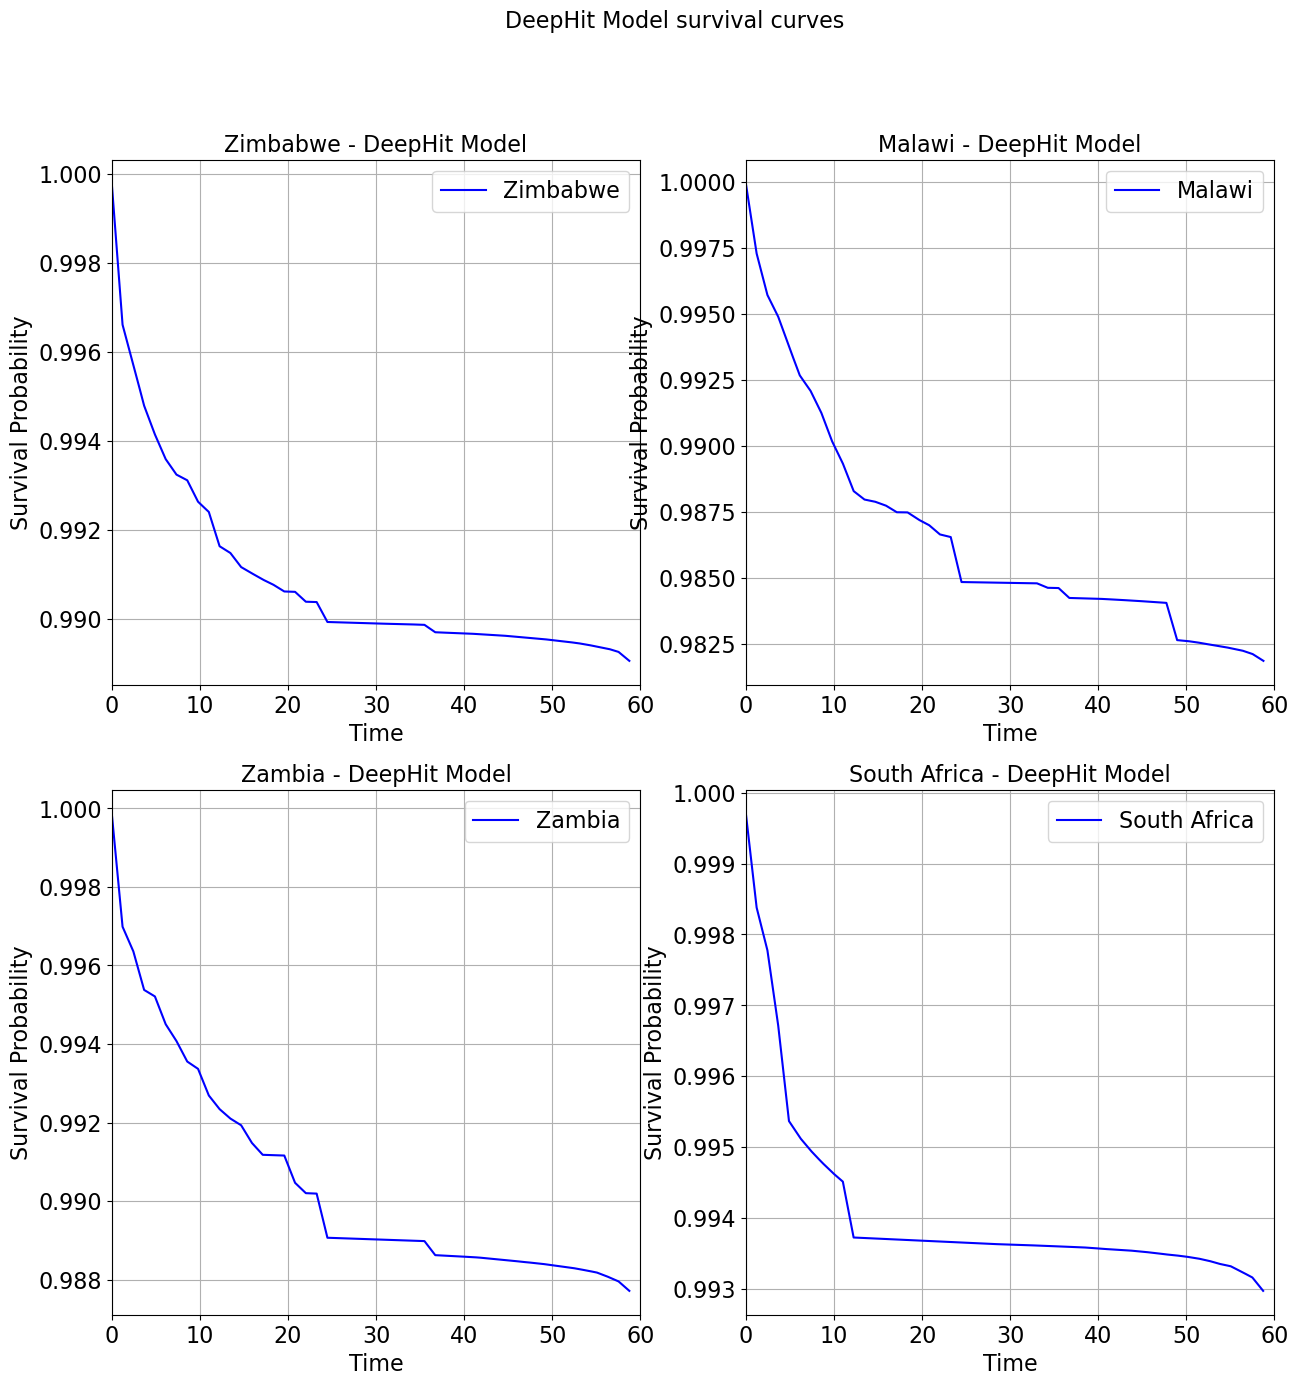

In [41]:
def plot_mean_survival_curves_for_countries(mean_survival_curves_dict):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))  
    axs = axs.flatten()  

    for i, country in enumerate(countries):
        
        
        survival_data_list = mean_survival_curves_dict[country]
        
        
        concatenated_df = pd.concat(survival_data_list, axis=1)
        
        
        mean_survival_probabilities = concatenated_df.mean(axis=1)
        
        
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)
        
        
        time_data = concatenated_df.index.values
        
        
        mean_survival_probabilities[mean_survival_probabilities < 0.97] = np.nan

        
        axs[i].plot(time_data, mean_survival_probabilities, label=f'{country}', color='blue')
        axs[i].set_title(f'{country} - DeepHit Model', fontsize=16)
        axs[i].set_xlabel('Time', fontsize=16)
        axs[i].set_ylabel('Survival Probability', fontsize=16)
        axs[i].legend(fontsize=16)
        axs[i].grid(True)
        axs[i].tick_params(axis="both", labelsize=16)
        
    
        axs[i].set_xlim(0, 60)  
        axs[i].set_xticks(np.arange(0, 61, 10))  
    fig.suptitle('DeepHit Model survival curves', fontsize=16)
    
    
    return fig, axs

fig, axs = plot_mean_survival_curves_for_countries(mean_survival_curves_dict_deephit)


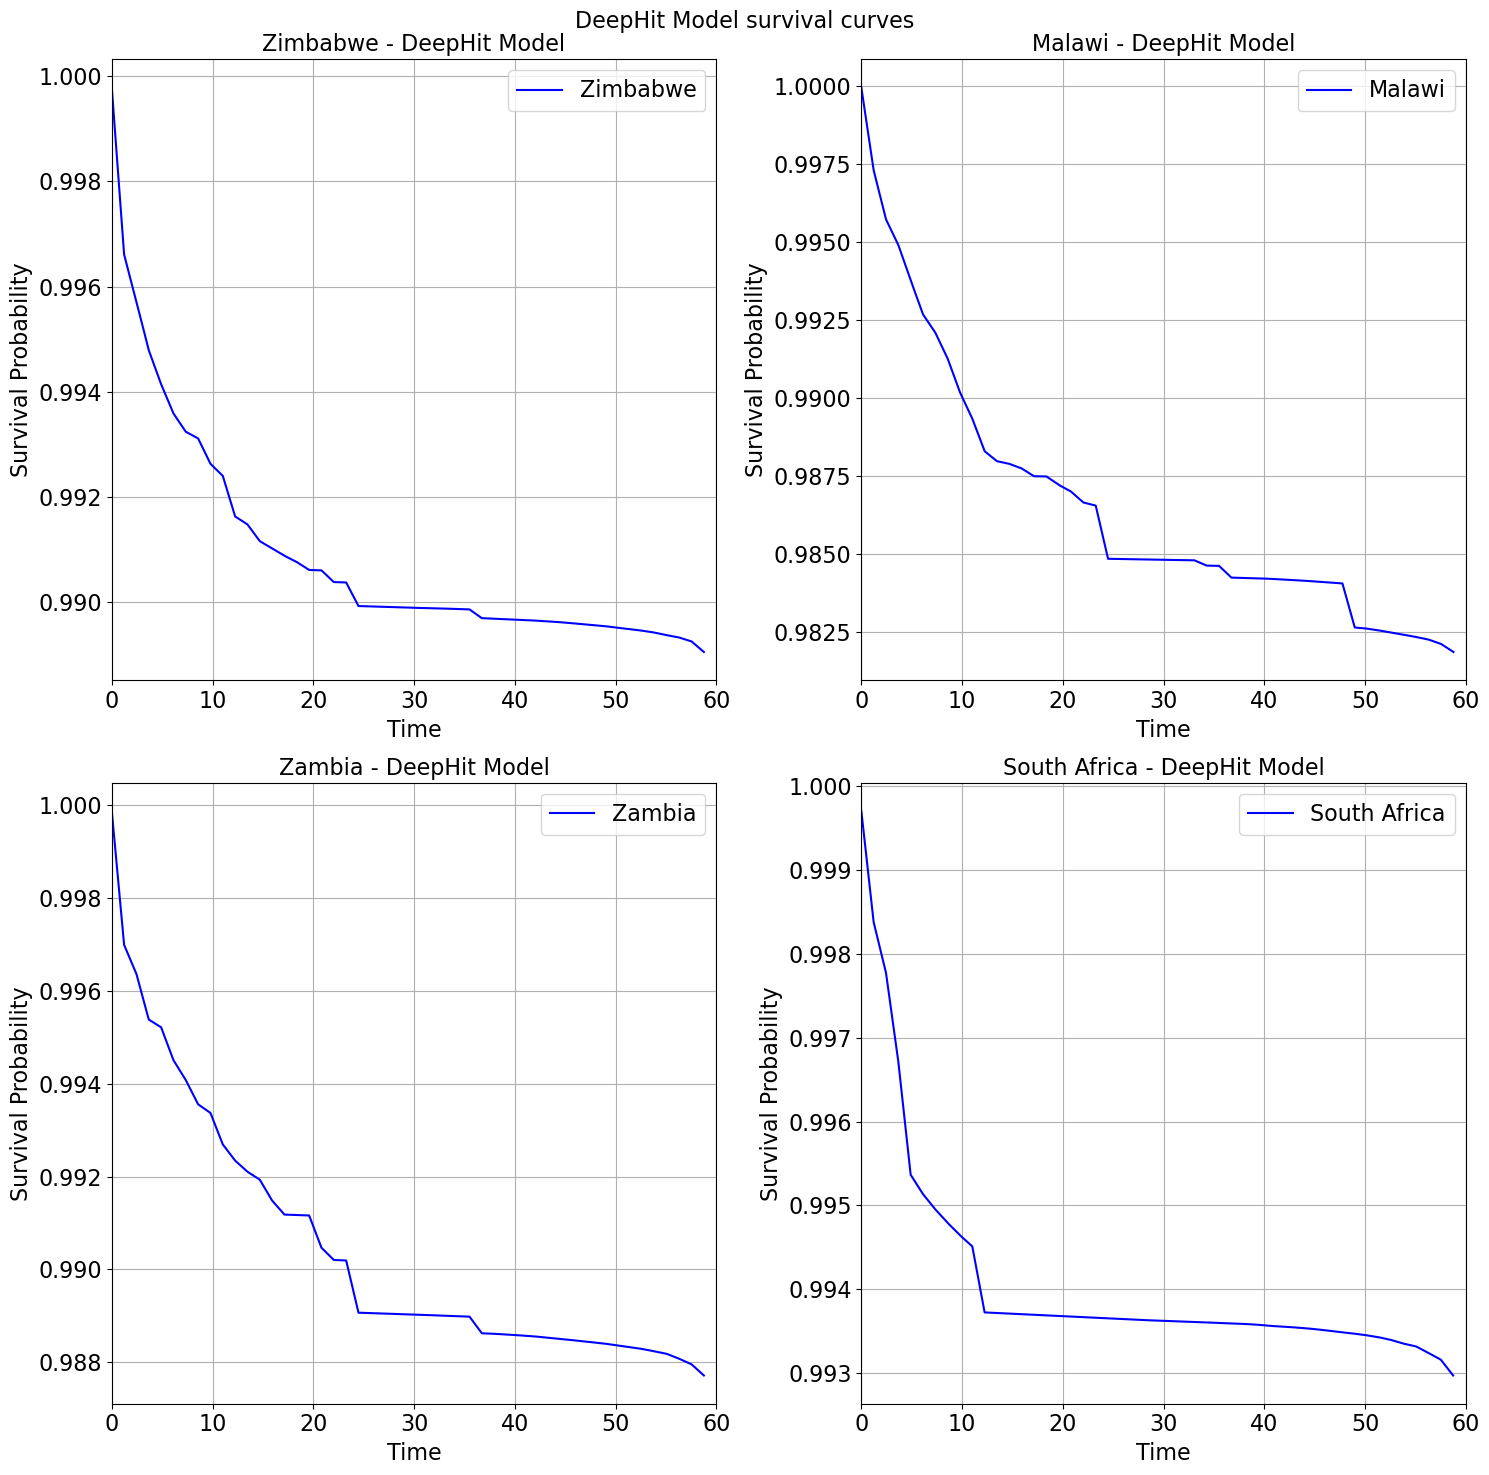

In [42]:
fig, axs = plot_mean_survival_curves_for_countries(mean_survival_curves_dict_deephit)
fig.tight_layout()
fig.savefig("plotDeephit_survProb.pdf")
plt.show()


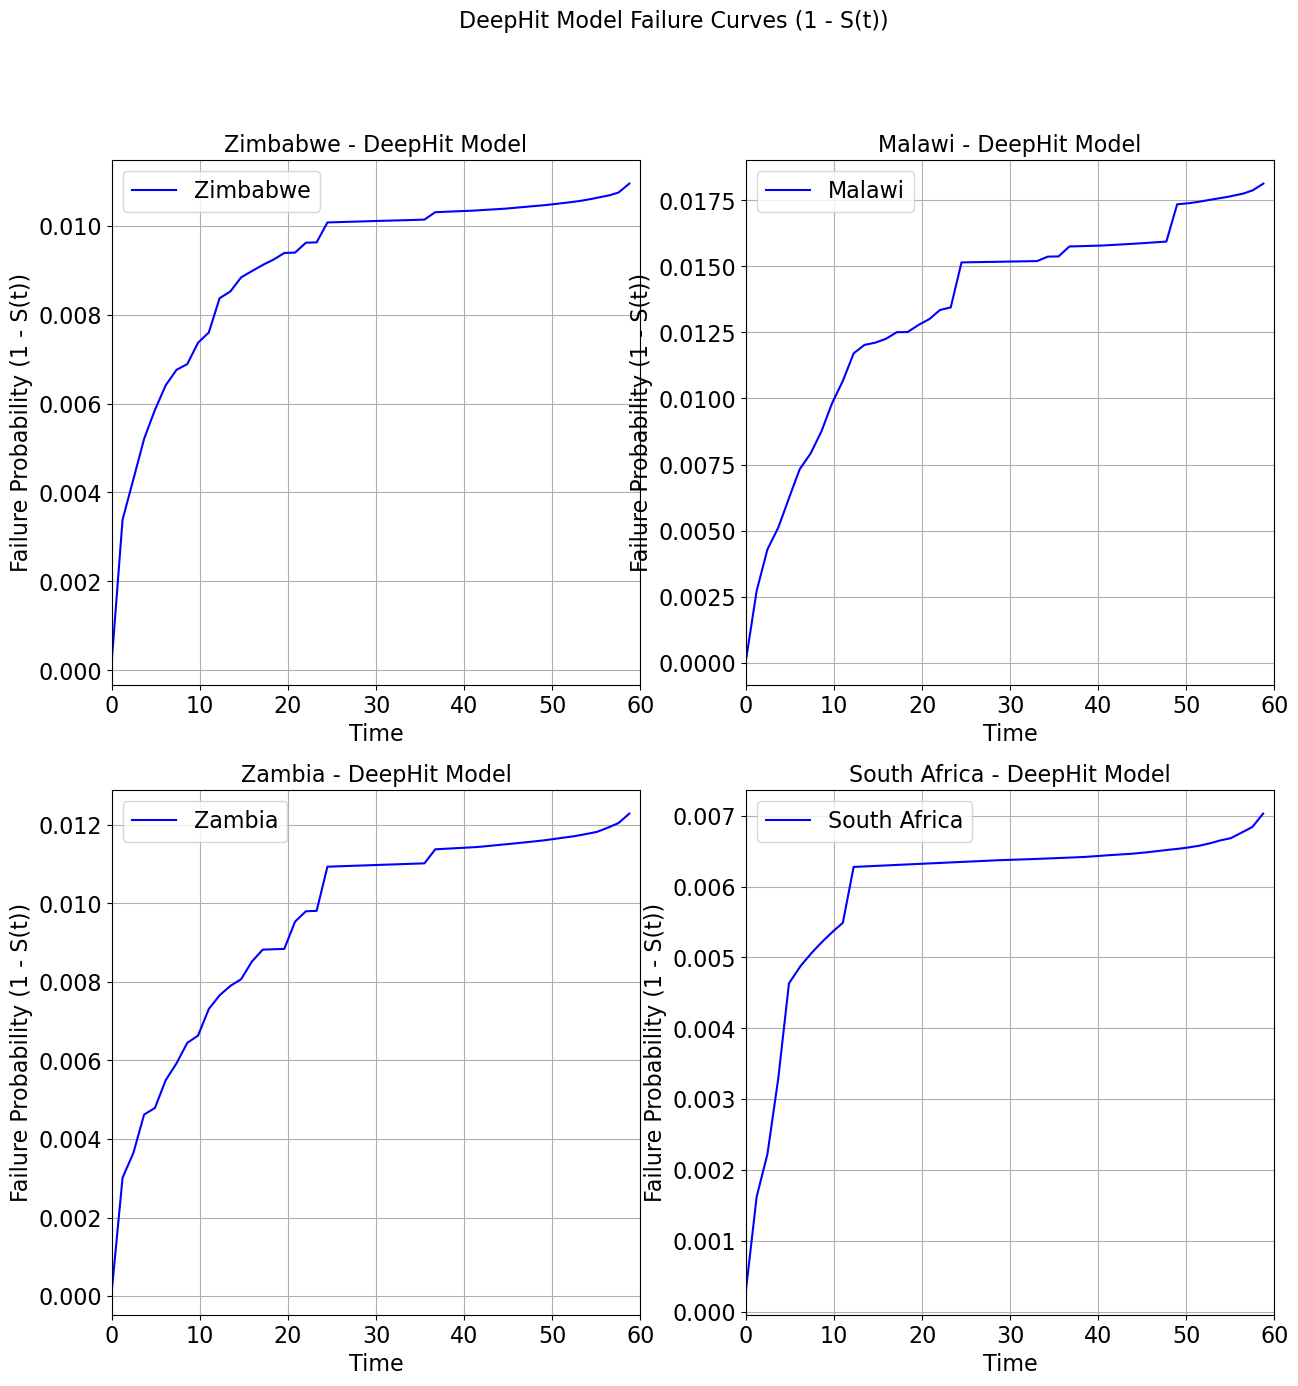

In [43]:
def plot_mean_failure_curves_for_countries(mean_survival_curves_dict):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))
    axs = axs.flatten()

    for i, country in enumerate(countries):
        
        
        survival_data_list = mean_survival_curves_dict[country]
        
    
        concatenated_df = pd.concat(survival_data_list, axis=1)
        
        
        mean_survival_probabilities = concatenated_df.mean(axis=1)
        
        
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)
        
    
        failure_probabilities = 1 - mean_survival_probabilities
        
    
        time_data = concatenated_df.index.values
        
        
        mask = mean_survival_probabilities > 0.97
        failure_plot = np.where(mask, failure_probabilities, np.nan)

        
        axs[i].plot(time_data, failure_plot, label=f'{country}', color='blue')
        axs[i].set_title(f'{country} - DeepHit Model', fontsize=16)
        axs[i].set_xlabel('Time', fontsize=16)
        axs[i].set_ylabel('Failure Probability (1 - S(t))', fontsize=16)
        axs[i].legend(fontsize=16)
        axs[i].grid(True)
        axs[i].tick_params(axis="both", labelsize=16)
        
    
        axs[i].set_xlim(0, 60)
        axs[i].set_xticks(np.arange(0, 61, 10))

    fig.suptitle('DeepHit Model Failure Curves (1 - S(t))', fontsize=16)

    return fig, axs



fig, axs = plot_mean_failure_curves_for_countries(mean_survival_curves_dict_deephit)

  


In [44]:
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
import os
from datetime import datetime
from sklearn.metrics import brier_score_loss


class SimpleMLPDeepHit(nn.Module):
    def __init__(self, in_features, num_durations, num_risks=1, num_nodes=[32, 32], dropout=0.1):
        super(SimpleMLPDeepHit, self).__init__()
        layers = []
        input_size = in_features
        for nodes in num_nodes:
            layers.append(nn.Linear(input_size, nodes))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_size = nodes
        layers.append(nn.Linear(input_size, num_durations))
        self.shared_net = nn.Sequential(*layers)
        self.logits = torch.nn.ModuleList([nn.Linear(num_durations, num_durations) for _ in range(num_risks)])

    def forward(self, x):
        h = self.shared_net(x)
        return [logit(h) for logit in self.logits]


def calculate_brier_score(surv, durations, events, time_point):
    
    closest_time_point = surv.index[(np.abs(surv.index - time_point)).argmin()]
    surv_at_time = surv.loc[closest_time_point].values
    brier = brier_score_loss(events, 1 - surv_at_time, pos_label=1)
    return brier, closest_time_point


def fit_deephit_model_cv(df, duration_col, event_col, dataset_name, folds=5, epochs=100, lr=0.01, batch_size=64):
    
    x = df.drop(columns=[duration_col, event_col]).values.astype(np.float32)
    y = (df[duration_col].values, df[event_col].values)

    
    num_durations = 50  
    labtrans = DeepHitSingle.label_transform(num_durations)
    y = labtrans.fit_transform(*y)
    

    assert np.all(np.diff(labtrans.cuts) > 0), "Cuts are not sorted properly."

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    mean_survival_curves = []
    c_index_results = []
    brier_score_results = []


    checkpoint_folder = os.path.expanduser("~/Desktop/Model_Checkpoints")
    os.makedirs(checkpoint_folder, exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(kf.split(x), 1):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = (y[0][train_idx], y[1][train_idx]), (y[0][val_idx], y[1][val_idx])

        net = SimpleMLPDeepHit(in_features=x_train.shape[1], num_durations=num_durations).to(device)
        model = DeepHitSingle(net, tt.optim.Adam, alpha=0.2, sigma=0.1, duration_index=labtrans.cuts)

    
        best_score = float('inf')
        for epoch in range(epochs):
            log = model.fit(x_train, y_train, batch_size, 1, val_data=(x_val, y_val), verbose=False)
            current_score = log.to_pandas()['val_loss'].values[-1]
            if current_score < best_score:
                best_score = current_score
                checkpoint_path = os.path.join(checkpoint_folder, f'best_model_fold_{fold}_epoch_{epoch + 1}.pt')
                torch.save(model.net.state_dict(), checkpoint_path)

    
        surv = model.interpolate(10).predict_surv_df(x_val)
        mean_survival_curves.append(surv)

    
        ev = EvalSurv(surv, y_val[0], y_val[1], censor_surv='km')
        c_index = ev.concordance_td('antolini')
        c_index_results.append(c_index)

    
        time_point = surv.index.values[-1] * 0.5  
        brier_score, closest_time_point = calculate_brier_score(surv, y_val[0], y_val[1], time_point)
        brier_score_results.append(brier_score)

        print(f'{dataset_name} - Fold {fold} C-index: {c_index}, Brier score at time {closest_time_point:.2f}: {brier_score}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results)
    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    print(f'{dataset_name} - Mean Brier score over {folds} folds: {mean_brier_score}')

    return mean_survival_curves, mean_c_index, mean_brier_score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mean_survival_curves_dict_deephit, c_index_dict_deephit, brier_score_dict_deephit = {}, {}, {}

for country, df in zip(['Zimbabwe', 'Malawi', 'Zambia', 'South Africa'], 
                       [zimbabwe_selected_df, malawi_selected_df, zambia_selected_df, sa_selected_df]):
    mean_survival_curves, mean_c_index, mean_brier_score = fit_deephit_model_cv(df, 'survival_time', 'Status_1', country)
    mean_survival_curves_dict_deephit[country] = mean_survival_curves
    c_index_dict_deephit[country] = mean_c_index
    brier_score_dict_deephit[country] = mean_brier_score



Zimbabwe - Fold 1 C-index: 0.6931464174454829, Brier score at time 30.00: 0.017821272027379643
Zimbabwe - Fold 2 C-index: 0.7954457738324971, Brier score at time 30.00: 0.012569224774895044
Zimbabwe - Fold 3 C-index: 0.8550934297769741, Brier score at time 30.00: 0.011448182223320847
Zimbabwe - Fold 4 C-index: 0.6379373848987109, Brier score at time 30.00: 0.014559964734380043
Zimbabwe - Fold 5 C-index: 0.9604015616285555, Brier score at time 30.00: 0.008203461189253025
Zimbabwe - Mean C-index over 5 folds: 0.788404913516444
Zimbabwe - Mean Brier score over 5 folds: 0.012920420989845721
Malawi - Fold 1 C-index: 0.9495672819177453, Brier score at time 30.00: 0.008582009695697038
Malawi - Fold 2 C-index: 0.8292649850827231, Brier score at time 30.00: 0.010212563375614473
Malawi - Fold 3 C-index: 0.742739322533137, Brier score at time 30.00: 0.012237079771051247
Malawi - Fold 4 C-index: 0.9236953661745358, Brier score at time 30.00: 0.007498498349564969
Malawi - Fold 5 C-index: 0.87893852

Great model discrimination

Great model calibration

## Random Survival Model

In [ ]:

from sklearn.model_selection import KFold
from sksurv.ensemble import RandomSurvivalForest

In [ ]:
def fit_rsf_model_cv(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    c_index_results = []
    brier_score_results = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Fit the Random Survival Forest model
        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        )
        rsf.fit(X_train, y_train)

        time_points = np.percentile(rsf.event_times_, [25, 50, 75])

        # Calculate C-index
        c_index = rsf.score(X_val, y_val)
        c_index_results.append(c_index)

        brier_scores = []
        surv_prob = rsf.predict_survival_function(X_val)

        # Get the time range for the survival functions
        surv_times = surv_prob[0].x
        min_time = surv_times[0]
        max_time = surv_times[-1]
    
        time_points = np.clip(time_points, min_time, max_time)

        for time_point in time_points:
            
            surv_prob_at_time = np.array([fn(time_point) for fn in surv_prob])
            # Compute Brier score
            brier_score_val = brier_score(y_train, y_val, surv_prob_at_time.reshape(-1, 1), times=[time_point])
            brier_scores.append(brier_score_val[1].mean())  
        brier_score_results.append(np.mean(brier_scores))

        print(f'{dataset_name} - Fold {fold + 1} C-index: {c_index}, Brier score: {np.mean(brier_scores)}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results)
    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    print(f'{dataset_name} - Mean Brier score over {folds} folds: {mean_brier_score}')

    return mean_c_index, mean_brier_score


mean_c_index_zimbabwe, mean_brier_zimbabwe = fit_rsf_model_cv(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe')
mean_c_index_malawi, mean_brier_malawi = fit_rsf_model_cv(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi')
mean_c_index_zambia, mean_brier_zambia = fit_rsf_model_cv(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia')
mean_c_index_sa, mean_brier_sa = fit_rsf_model_cv(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')


print("\nSummary of Random Survival Forest Model Results:")
print(f"Zimbabwe - Mean C-index: {mean_c_index_zimbabwe}, Mean Brier score: {mean_brier_zimbabwe}")
print(f"Malawi - Mean C-index: {mean_c_index_malawi}, Mean Brier score: {mean_brier_malawi}")
print(f"Zambia - Mean C-index: {mean_c_index_zambia}, Mean Brier score: {mean_brier_zambia}")
print(f"South Africa - Mean C-index: {mean_c_index_sa}, Mean Brier score: {mean_brier_sa}")


Great model discrimination

Great model calibration

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import KFold
from datetime import datetime


def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    time_grid = np.linspace(1, 24, 100)
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        for fold_idx, surv in enumerate(surv_curves):
            times = surv[0].x  
            survival_probs = np.mean([fn(time_grid) for fn in surv], axis=0)
            axes[i].plot(time_grid, survival_probs, label=f'Fold {fold_idx + 1}')
        
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    plt.tight_layout()
    
    plots_folder = "C:/Users/cyrch/OneDrive - University of Witwatersrand/Desktop_hp/Side Projects/Mafa/Zim_Malawi_New/Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_file_path = os.path.join(plots_folder, f'RSF_Survival_Plots_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.png')
    plt.savefig(plot_file_path)
    plt.show()

def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    # Prepare the data
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()], dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # Cross-validation
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        rsf = RandomSurvivalForest(n_estimators=n_estimators, min_samples_split=10, min_samples_leaf=15, max_features="sqrt", n_jobs=-1, random_state=42)
        rsf.fit(X_train, y_train)
        
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves

surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')


In [ ]:
#surv_curves_dict_rsf

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime

def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []
        all_times = []
        for surv_prob in surv_curves:
            all_surv_funcs.extend(surv_prob)
        
            for fn in surv_prob:
                all_times.extend(fn.x)
        
        min_time = min(all_times)
        max_time = max(all_times)
        common_times = np.linspace(min_time, max_time, 100)
        
        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(common_times)))
        for idx, fn in enumerate(all_surv_funcs):
            # Clip common_times to the domain of the function
            valid_times = np.clip(common_times, fn.x[0], fn.x[-1])
            surv_probs_matrix[idx, :] = fn(valid_times)
        
        mean_surv_probs = np.mean(surv_probs_matrix, axis=0)
        
        axes[i].plot(common_times, mean_surv_probs, label=f'Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}', fontsize=16)
        axes[i].set_xlabel('Time', fontsize=16)
        axes[i].set_ylabel('Survival Probability', fontsize=16)
        axs[i].tick_params(axis="both", labelsize=16)
        axes[i].legend(loc='best',fontsize=16)
        axes[i].grid(True)
    
    fig.suptitle('Random Survival Forest Model survival curves', fontsize=16)
    plt.show()

def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    # Prepare the data
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
    
        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold  
        )
        rsf.fit(X_train, y_train)
        
        
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves


surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')




In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored


def permutation_importance(rsf, X_val, y_val, baseline_cindex):
    importance_scores = np.zeros(X_val.shape[1])
    for col in range(X_val.shape[1]):
        X_val_permuted = X_val.copy()
        np.random.shuffle(X_val_permuted[:, col])  # Shuffle one feature at a time
        cindex_permuted = rsf.score(X_val_permuted, y_val)
        importance_scores[col] = baseline_cindex - cindex_permuted
    return importance_scores

def fit_rsf_model_cv(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    feature_importance_results = np.zeros(X.shape[1])

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        )
        rsf.fit(X_train, y_train)

        baseline_cindex = rsf.score(X_val, y_val)

        importance_scores = permutation_importance(rsf, X_val, y_val, baseline_cindex)
        feature_importance_results += importance_scores

    feature_importance_results /= folds

    feature_importance_df = pd.DataFrame({
        'Feature': df.drop(columns=[duration_col, event_col]).columns,
        'Importance': feature_importance_results
    })

    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    return feature_importance_df

for dataset_name, df in [('Zimbabwe', zimbabwe_selected_df), ('Malawi', malawi_selected_df),
                         ('Zambia', zambia_selected_df), ('South Africa', sa_selected_df)]:
    df['survival_time'] = np.random.randint(1, 1000, size=len(df))  
    df['Status_1'] = np.random.randint(0, 2, size=len(df))          

datasets = [
    ('Zimbabwe', zimbabwe_selected_df),
    ('Malawi', malawi_selected_df),
    ('Zambia', zambia_selected_df),
    ('South Africa', sa_selected_df)
]

for dataset_name, df in datasets:
    feature_importance_df = fit_rsf_model_cv(df, 'survival_time', 'Status_1', dataset_name)
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.xlabel('Feature Importance')
    plt.ylabel('Features')
    plt.title(f'Feature Importance for {dataset_name}')
    plt.gca().invert_yaxis()  # Invert y-axis to show the largest importance at the top
    plt.tight_layout()
    plt.show()


In [ ]:
zimbabwe_selected_df.shape
#malawi_selected_df
#zambia_selected_df
#sa_selected_df


In [ ]:

for dataset_name, df in datasets:
    print(f"Columns for {dataset_name}: {df.columns}")


## COX Model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from lifelines import CoxPHFitter
from sklearn.model_selection import KFold
def plot_mean_survival_curves_cox(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        for fold_idx, surv in enumerate(surv_curves):
            axes[i].plot(surv.index, surv.values.mean(axis=1), label=f'Fold {fold_idx + 1}')
        
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    fig.suptitle('Cox Model survival curves', fontsize=16)
    plt.show()

def fit_cox_and_collect_survival_curves(df, duration_col, event_col, dataset_name, folds=5):
    surv_curves = []
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_data = df.iloc[train_idx]
        val_data = df.iloc[val_idx]
        
        cph = CoxPHFitter()
        cph.fit(train_data, duration_col=duration_col, event_col=event_col)
        
        surv_prob = cph.predict_survival_function(val_data)
        surv_curves.append(surv_prob)
    
    return surv_curves

surv_curves_dict_cox = {
    'Zimbabwe': fit_cox_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_cox_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_cox_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_cox_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_cox(surv_curves_dict_cox, 'Cox Proportional Hazards Model')


In [ ]:
import numpy as np
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import KFold
from sklearn.metrics import brier_score_loss


def calculate_brier_score_cph(surv, durations, events, time_point):
    closest_time_point = surv.index[np.abs(surv.index - time_point).argmin()]
    surv_at_time = surv.loc[closest_time_point].values
    brier = brier_score_loss(events, 1 - surv_at_time, pos_label=1)
    return brier, closest_time_point

def fit_cox_model_cv(df, duration_col, event_col, dataset_name, folds=5):
    df = df.copy()
    for col in df.select_dtypes(include=['category', 'object']).columns:
        df[col] = df[col].astype('category').cat.codes

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    c_index_results = []
    brier_score_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_data = df.iloc[train_idx]
        val_data = df.iloc[val_idx]
        
        cph = CoxPHFitter()
        cph.fit(train_data, duration_col=duration_col, event_col=event_col)
        
        c_index = cph.concordance_index_
        c_index_results.append(c_index)
        
        surv = cph.predict_survival_function(val_data)
        time_point = surv.index.values[-1] * 0.5  
        brier_score_val, closest_time_point = calculate_brier_score_cph(surv, val_data[duration_col], val_data[event_col], time_point)
        brier_score_results.append(brier_score_val)
        
        print(f'{dataset_name} - Fold {fold + 1} C-index: {c_index}, Brier score at time {closest_time_point:.2f}: {brier_score_val}')

    mean_c_index = np.mean(c_index_results)
    mean_brier_score = np.mean(brier_score_results)
    
    print(f'{dataset_name} - Mean C-index over {folds} folds: {mean_c_index}')
    print(f'{dataset_name} - Mean Brier score over {folds} folds: {mean_brier_score}')
    
    return mean_c_index, mean_brier_score

for country, df in zip(['Zimbabwe', 'Malawi', 'Zambia', 'South Africa'], 
                       [zimbabwe_selected_df, malawi_selected_df, zambia_selected_df, sa_selected_df]):
    mean_c_index, mean_brier_score = fit_cox_model_cv(df, 'survival_time', 'Status_1', country)


Great model discrimination

Great model calibration

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from sklearn.model_selection import KFold

def plot_survival_curves_cph_frailty(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for i, (country, surv_curves) in enumerate(surv_curves_dict.items()):
        for fold_idx, surv in enumerate(surv_curves):
            if surv.empty or surv.shape[0] == 0:  
                continue
            times = surv.index
            survival_probs = surv.mean(axis=1)
            axes[i].plot(times, survival_probs, label=f'Fold {fold_idx + 1}')
        axes[i].set_title(f'{country} - Cox Model with Frailty')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend()
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('Plots/cox_frailty_survival_curves.png')
    plt.show()

def fit_cox_model_cv(df, duration_col, event_col, strata_col, dataset_name, folds=5):
    df = df.copy()

    df = df.dropna()

    if strata_col in df.columns:
        df[strata_col] = df[strata_col].astype('category')
    else:
        print(f"Column {strata_col} not found in dataset {dataset_name}.")
        return []

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_data = df.iloc[train_idx]
        val_data = df.iloc[val_idx]

        if len(train_data) == 0 or len(val_data) == 0:
            print(f"Skipping fold {fold + 1} for {dataset_name} due to insufficient data.")
            continue
        
        try:
            if val_data.shape[0] < 3:
                print(f"Skipping fold {fold + 1} for {dataset_name}: insufficient samples in validation set.")
                continue
            cph = CoxPHFitter(penalizer=0.1)  
            cph.fit(train_data, duration_col=duration_col, event_col=event_col, strata=[strata_col])
            
            # Predict survival function for the validation set
            surv = cph.predict_survival_function(val_data)
            
            if surv.shape[0] > 0 and surv.shape[1] > 0:  
                surv_curves.append(surv)
            else:
                surv_curves.append(pd.DataFrame())  
            
        except Exception as e:
            print(f"Error fitting Cox model in fold {fold + 1} for {dataset_name}: {e}")
            surv_curves.append(pd.DataFrame())  

    return surv_curves

surv_curves_dict_cph_frailty = {
    'Zimbabwe': fit_cox_model_cv(zimbabwe_selected_df, 'survival_time', 'Status', 'V208_recoded', 'Zimbabwe'),
    'Malawi': fit_cox_model_cv(malawi_selected_df, 'survival_time', 'Status', 'V208_recoded', 'Malawi'),
    'Zambia': fit_cox_model_cv(zambia_selected_df, 'survival_time', 'Status', 'V208_recoded', 'Zambia'),
    'South Africa': fit_cox_model_cv(sa_selected_df, 'survival_time', 'Status', 'V208_recoded', 'South Africa')
}

plot_survival_curves_cph_frailty(surv_curves_dict_cph_frailty, 'Cox Model with Frailty - Survival Curves')


In [ ]:
def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from datetime import datetime

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    time_grid = np.linspace(0, 60, 100) 

    for i, (country, surv_curves_per_fold) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []  
        for surv_funcs in surv_curves_per_fold:
            all_surv_funcs.extend(surv_funcs)
        survival_matrix = np.array([[fn(t) for t in time_grid] for fn in all_surv_funcs])
        mean_survival = survival_matrix.mean(axis=0)

        axes[i].plot(time_grid, mean_survival, label='Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    plt.tight_layout()

    plots_folder = "C:/Users/cyrch/OneDrive - University of Witwatersrand/Desktop_hp/Side Projects/Mafa/Zim_Malawi_New/Plots"
    os.makedirs(plots_folder, exist_ok=True)
    plot_file_path = os.path.join(plots_folder, f'RSF_Survival_Plots_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.png')
    plt.savefig(plot_file_path)
    plt.show()


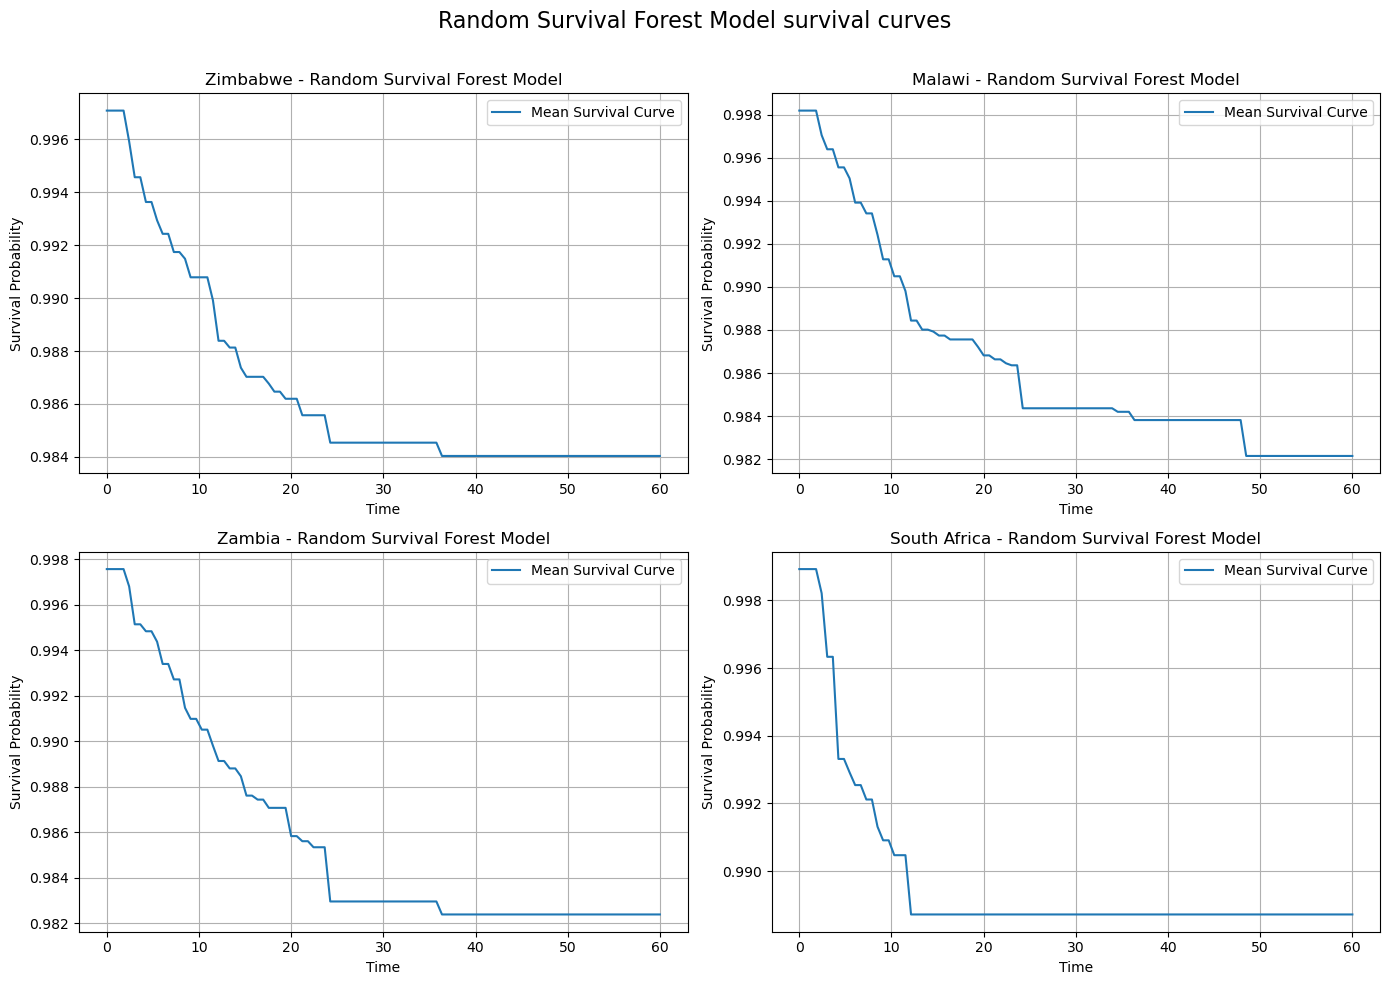

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest
from datetime import datetime


def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold
        )
        rsf.fit(X_train, y_train)
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves


def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    time_grid = np.linspace(0, 60, 100)  

    for i, (country, surv_curves_per_fold) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []
        for fold in surv_curves_per_fold:
            all_surv_funcs.extend(fold)

        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(time_grid)))

        for j, fn in enumerate(all_surv_funcs):
            y_vals = fn(fn.x)
            first_val = y_vals[0]
            last_val = y_vals[-1]
            extended_vals = np.array([
                fn(t) if fn.x[0] <= t <= fn.x[-1] else
                (first_val if t < fn.x[0] else last_val)
                for t in time_grid
            ])
            surv_probs_matrix[j, :] = extended_vals

        mean_surv = surv_probs_matrix.mean(axis=0)
        axes[i].plot(time_grid, mean_surv, label='Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}')
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Survival Probability')
        axes[i].legend(loc='best')
        axes[i].grid(True)

    fig.suptitle('Random Survival Forest Model survival curves', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')




In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest
from datetime import datetime
import os


try:
    from IPython.display import FileLink, display
    JUPYTER = True
except ImportError:
    JUPYTER = False


def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold
        )
        rsf.fit(X_train, y_train)
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves

def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    axes = axes.flatten()
    time_grid = np.linspace(0, 60, 100)  # Fixed time grid

    for i, (country, surv_curves_per_fold) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []
        for fold in surv_curves_per_fold:
            all_surv_funcs.extend(fold)

        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(time_grid)))

        for j, fn in enumerate(all_surv_funcs):
            y_vals = fn(fn.x)
            first_val = y_vals[0]
            last_val = y_vals[-1]
            extended_vals = np.array([
                fn(t) if fn.x[0] <= t <= fn.x[-1] else
                (first_val if t < fn.x[0] else last_val)
                for t in time_grid
            ])
            surv_probs_matrix[j, :] = extended_vals

        mean_surv = surv_probs_matrix.mean(axis=0)
        axes[i].plot(time_grid, mean_surv, label='Mean Survival Curve')
        axes[i].set_title(f'{country} - {title}',fontsize=16)
        axes[i].set_xlabel('Time',fontsize=16)
        axes[i].set_ylabel('Survival Probability',fontsize=16)
        axes[i].legend(loc='best',fontsize=16)
        axes[i].grid(True)

    fig.suptitle('Random Survival Forest Model survival curves', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    filename = f"RSF_Survival_Curves_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"
    fig.savefig(filename, dpi=300)
    print(f"✅ Plot saved as: {filename}")
    plt.show()

    if JUPYTER:
        display(FileLink(filename, result_html_prefix="📥 Click to download: "))


✅ Plot saved as: RSF_Survival_Curves_2026-05-15_14-14-39.pdf


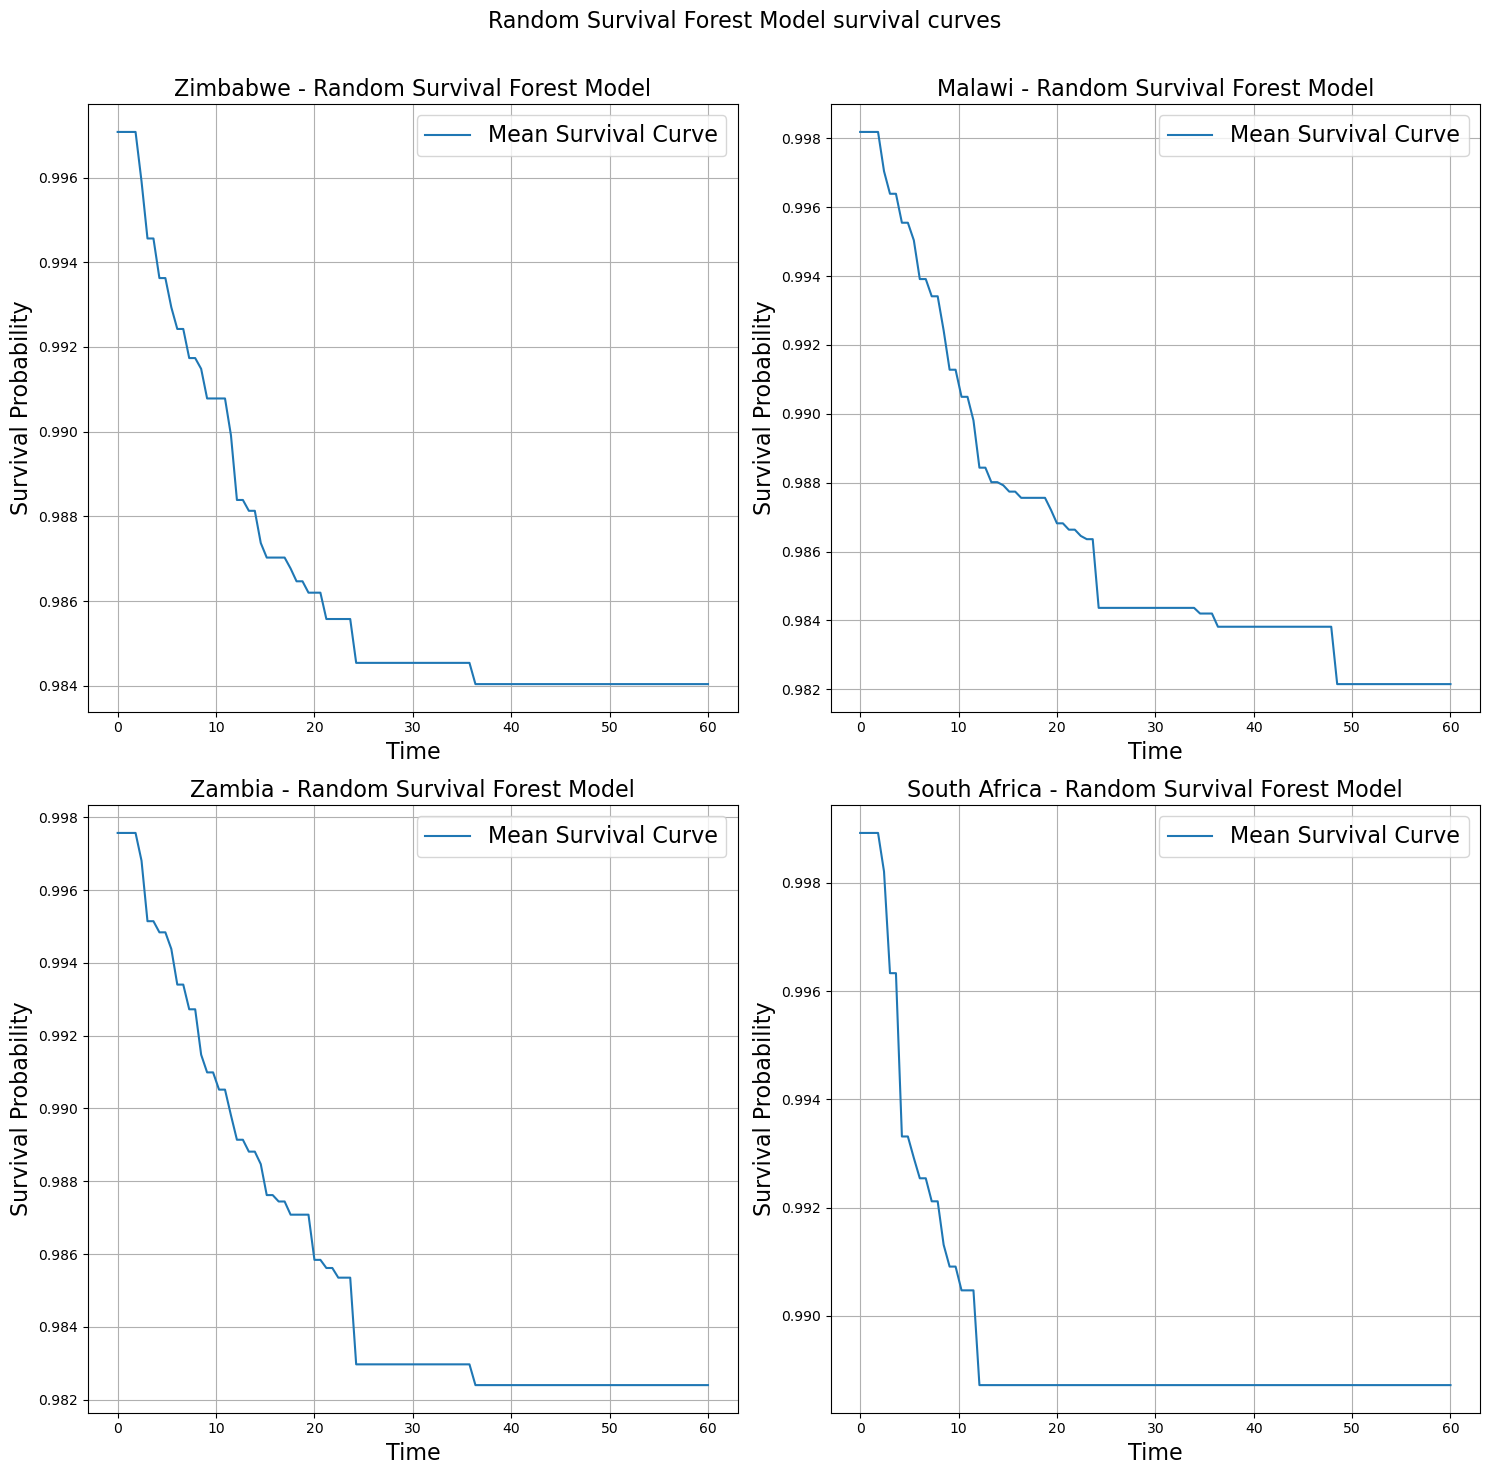

/home/justine/RSF_Survival_Curves_2026-05-15_14-14-39.pdf

In [51]:

surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')


✅ Plot saved as: RSF_1_minus_S_t_Curves_2026-05-15_14-16-09.pdf


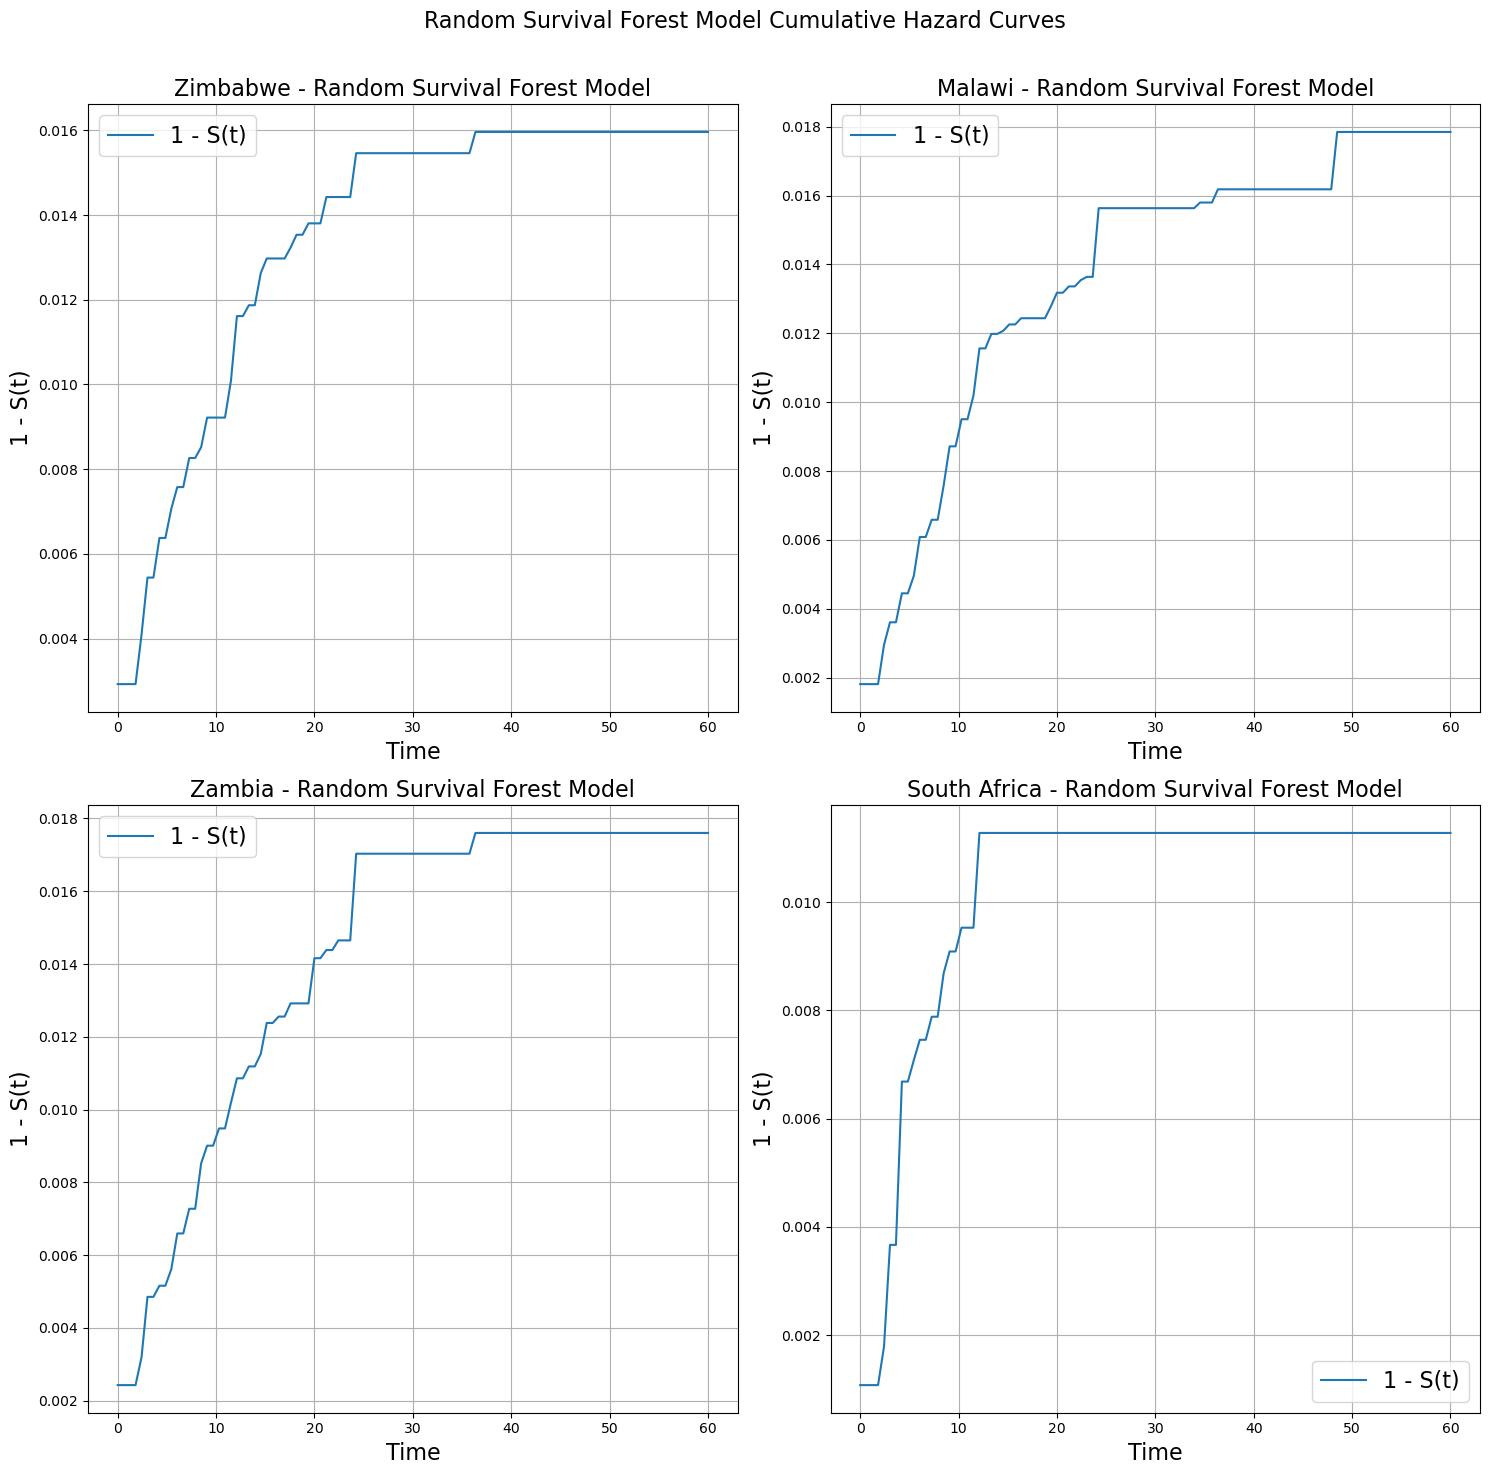

/home/justine/RSF_1_minus_S_t_Curves_2026-05-15_14-16-09.pdf

In [52]:
def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name, n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold
        )
        rsf.fit(X_train, y_train)
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves


def plot_mean_survival_curves_rsf(surv_curves_dict, title):
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    axes = axes.flatten()
    time_grid = np.linspace(0, 60, 100)  

    for i, (country, surv_curves_per_fold) in enumerate(surv_curves_dict.items()):
        all_surv_funcs = []
        for fold in surv_curves_per_fold:
            all_surv_funcs.extend(fold)

        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(time_grid)))

        for j, fn in enumerate(all_surv_funcs):
            y_vals = fn(fn.x)
            first_val = y_vals[0]
            last_val = y_vals[-1]
            extended_vals = np.array([
                fn(t) if fn.x[0] <= t <= fn.x[-1] else
                (first_val if t < fn.x[0] else last_val)
                for t in time_grid
            ])
            surv_probs_matrix[j, :] = extended_vals

        mean_surv = surv_probs_matrix.mean(axis=0)
        mean_failure = 1 - mean_surv

        axes[i].plot(time_grid, mean_failure, label='1 - S(t)')
        axes[i].set_title(f'{country} - {title}', fontsize=16)
        axes[i].set_xlabel('Time', fontsize=16)
        axes[i].set_ylabel('1 - S(t)', fontsize=16)
        axes[i].legend(loc='best', fontsize=16)
        axes[i].grid(True)

    fig.suptitle('Random Survival Forest Model Cumulative Hazard Curves', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    filename = f"RSF_1_minus_S_t_Curves_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"
    fig.savefig(filename, dpi=300)
    print(f"✅ Plot saved as: {filename}")
    plt.show()

    if JUPYTER:
        display(FileLink(filename, result_html_prefix="📥 Click to download: "))

surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}

plot_mean_survival_curves_rsf(surv_curves_dict_rsf, 'Random Survival Forest Model')

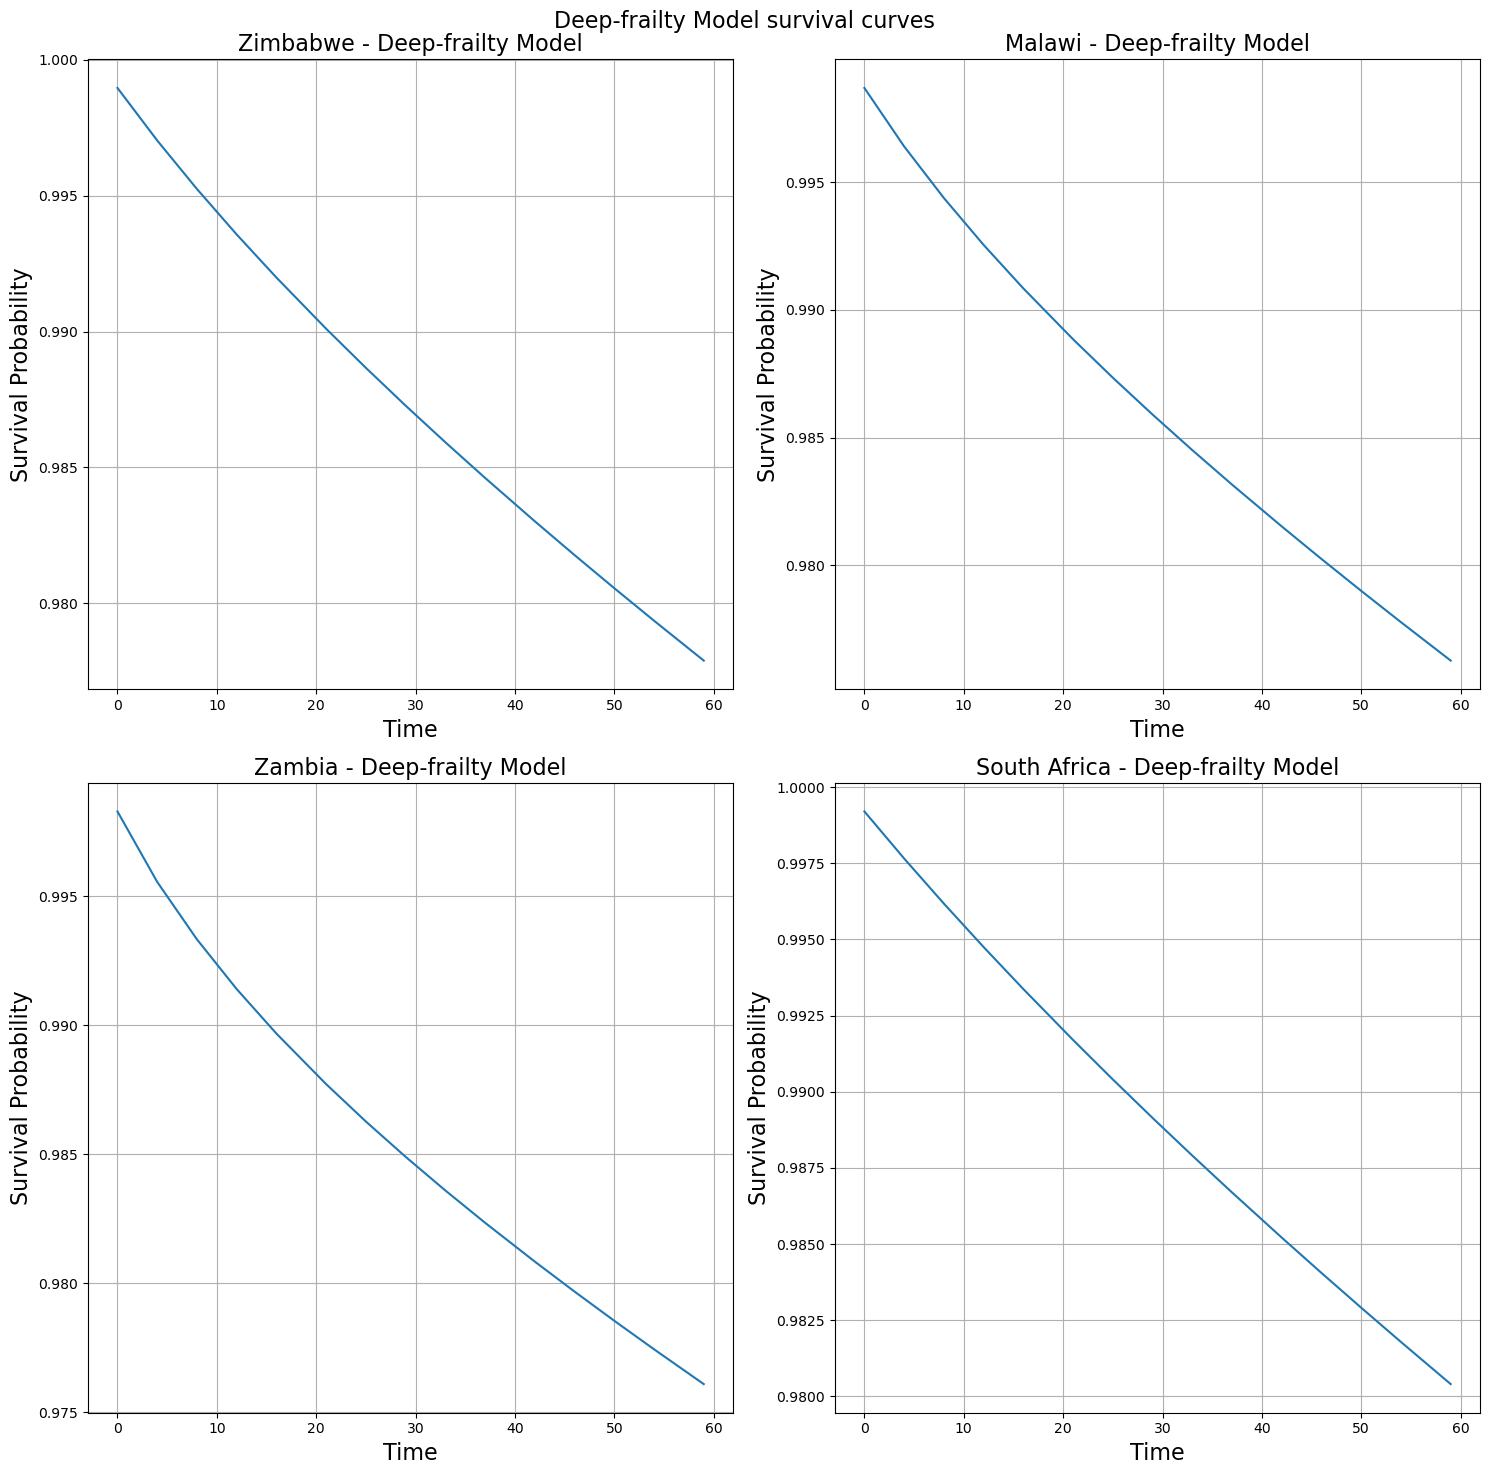

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the datasets (replace with your actual CSV files)
dfZim = pd.read_csv('Zimbabwe_resultssurvivalFULL.csv')
dfZamb = pd.read_csv('Zambia_resultssurvivalFULL.csv')
dfSouth = pd.read_csv('SouthAfrica_resultssurvivalFULL.csv')
dfMalawi = pd.read_csv('Malawi_resultssurvivalFULL.csv')

mean_Zim = dfZim.mean()
mean_Zamb = dfZamb.mean()
mean_South = dfSouth.mean()
mean_Malawi = dfMalawi.mean()

time_points = np.linspace(0, 59, num=15, dtype=int) 

plt.style.use('default')

fig, axs = plt.subplots(2, 2, figsize=(15, 15), facecolor='white')

# Zimbabwe
axs[0, 0].plot(time_points, mean_Zim[time_points].values, label='Fold 1')
axs[0, 0].set_title('Zimbabwe - Deep-frailty Model',fontsize=16)
axs[0, 0].set_xlabel('Time',fontsize=16)
axs[0, 0].set_ylabel('Survival Probability',fontsize=16)
axs[0, 0].grid(True)

# Malawi
axs[0, 1].plot(time_points, mean_Malawi[time_points].values, label='Fold 1')
axs[0, 1].set_title('Malawi - Deep-frailty Model',fontsize=16)
axs[0, 1].set_xlabel('Time',fontsize=16)
axs[0, 1].set_ylabel('Survival Probability',fontsize=16)
axs[0, 1].grid(True)

# Zambia
axs[1, 0].plot(time_points, mean_Zamb[time_points].values, label='Fold 1')
axs[1, 0].set_title('Zambia - Deep-frailty Model',fontsize=16)
axs[1, 0].set_xlabel('Time',fontsize=16)
axs[1, 0].set_ylabel('Survival Probability',fontsize=16)
axs[1, 0].grid(True)

# South Africa
axs[1, 1].plot(time_points, mean_South[time_points].values, label='Fold 1')
axs[1, 1].set_title('South Africa - Deep-frailty Model',fontsize=16)
axs[1, 1].set_xlabel('Time',fontsize=16)
axs[1, 1].set_ylabel('Survival Probability',fontsize=16)
axs[1, 1].grid(True)
fig.suptitle('Deep-frailty Model survival curves', fontsize=16)
# Adjust layout to prevent overlap
plt.tight_layout()


plt.show()



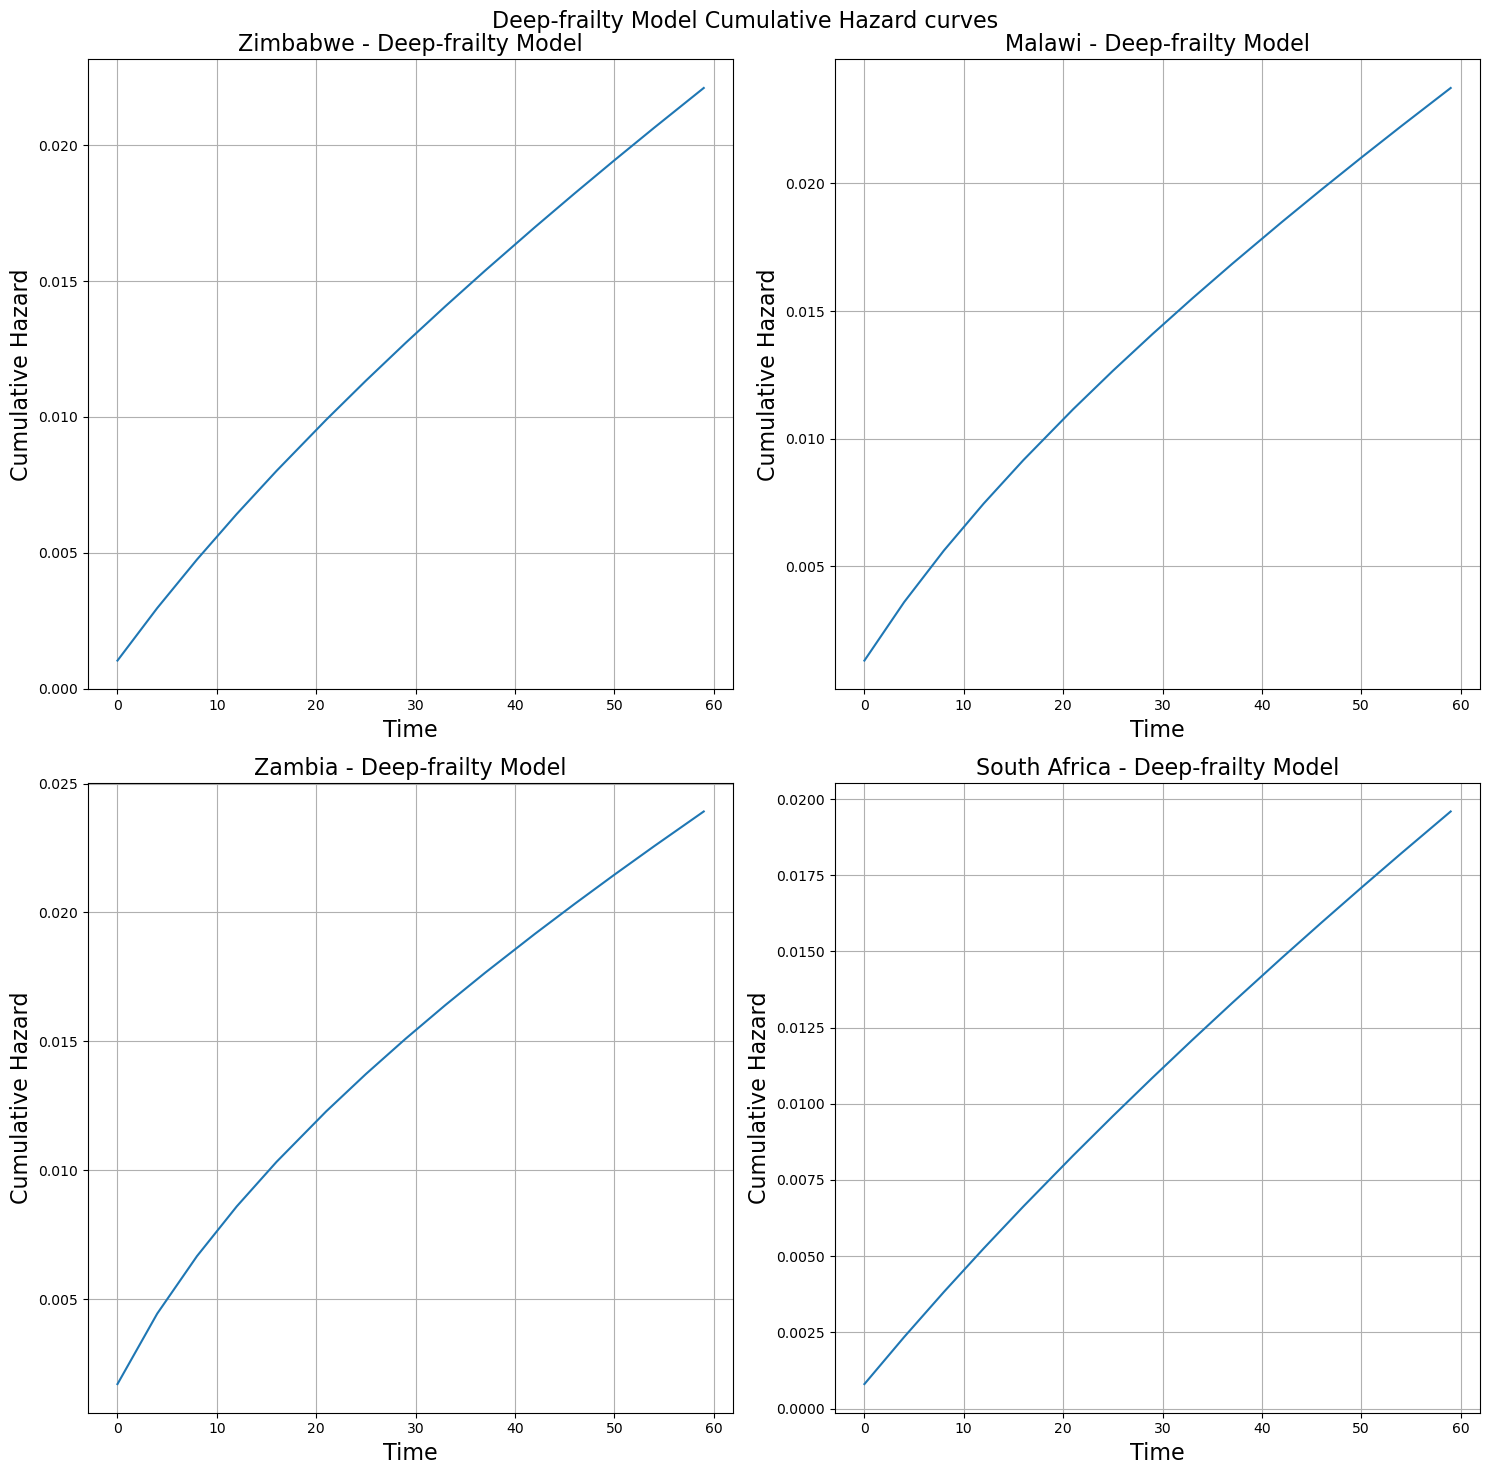

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


dfZim = pd.read_csv('Zimbabwe_resultssurvivalFULL.csv')
dfZamb = pd.read_csv('Zambia_resultssurvivalFULL.csv')
dfSouth = pd.read_csv('SouthAfrica_resultssurvivalFULL.csv')
dfMalawi = pd.read_csv('Malawi_resultssurvivalFULL.csv')


mean_Zim = dfZim.mean()
mean_Zamb = dfZamb.mean()
mean_South = dfSouth.mean()
mean_Malawi = dfMalawi.mean()

fail_Zim = 1 - mean_Zim
fail_Zamb = 1 - mean_Zamb
fail_South = 1 - mean_South
fail_Malawi = 1 - mean_Malawi


time_points = np.linspace(0, 59, num=15, dtype=int)


plt.style.use('default')


fig, axs = plt.subplots(2, 2, figsize=(15, 15), facecolor='white')

# Zimbabwe
axs[0, 0].plot(time_points, fail_Zim[time_points].values, label='1 - S(t)')
axs[0, 0].set_title('Zimbabwe - Deep-frailty Model', fontsize=16)
axs[0, 0].set_xlabel('Time', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Hazard', fontsize=16)
axs[0, 0].grid(True)

# Malawi
axs[0, 1].plot(time_points, fail_Malawi[time_points].values, label='1 - S(t)')
axs[0, 1].set_title('Malawi - Deep-frailty Model', fontsize=16)
axs[0, 1].set_xlabel('Time', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Hazard', fontsize=16)
axs[0, 1].grid(True)

# Zambia
axs[1, 0].plot(time_points, fail_Zamb[time_points].values, label='1 - S(t)')
axs[1, 0].set_title('Zambia - Deep-frailty Model', fontsize=16)
axs[1, 0].set_xlabel('Time', fontsize=16)
axs[1, 0].set_ylabel('Cumulative Hazard', fontsize=16)
axs[1, 0].grid(True)

# South Africa
axs[1, 1].plot(time_points, fail_South[time_points].values, label='1 - S(t)')
axs[1, 1].set_title('South Africa - Deep-frailty Model', fontsize=16)
axs[1, 1].set_xlabel('Time', fontsize=16)
axs[1, 1].set_ylabel('Cumulative Hazard', fontsize=16)
axs[1, 1].grid(True)

fig.suptitle('Deep-frailty Model Cumulative Hazard curves', fontsize=16)

plt.tight_layout()
plt.show()

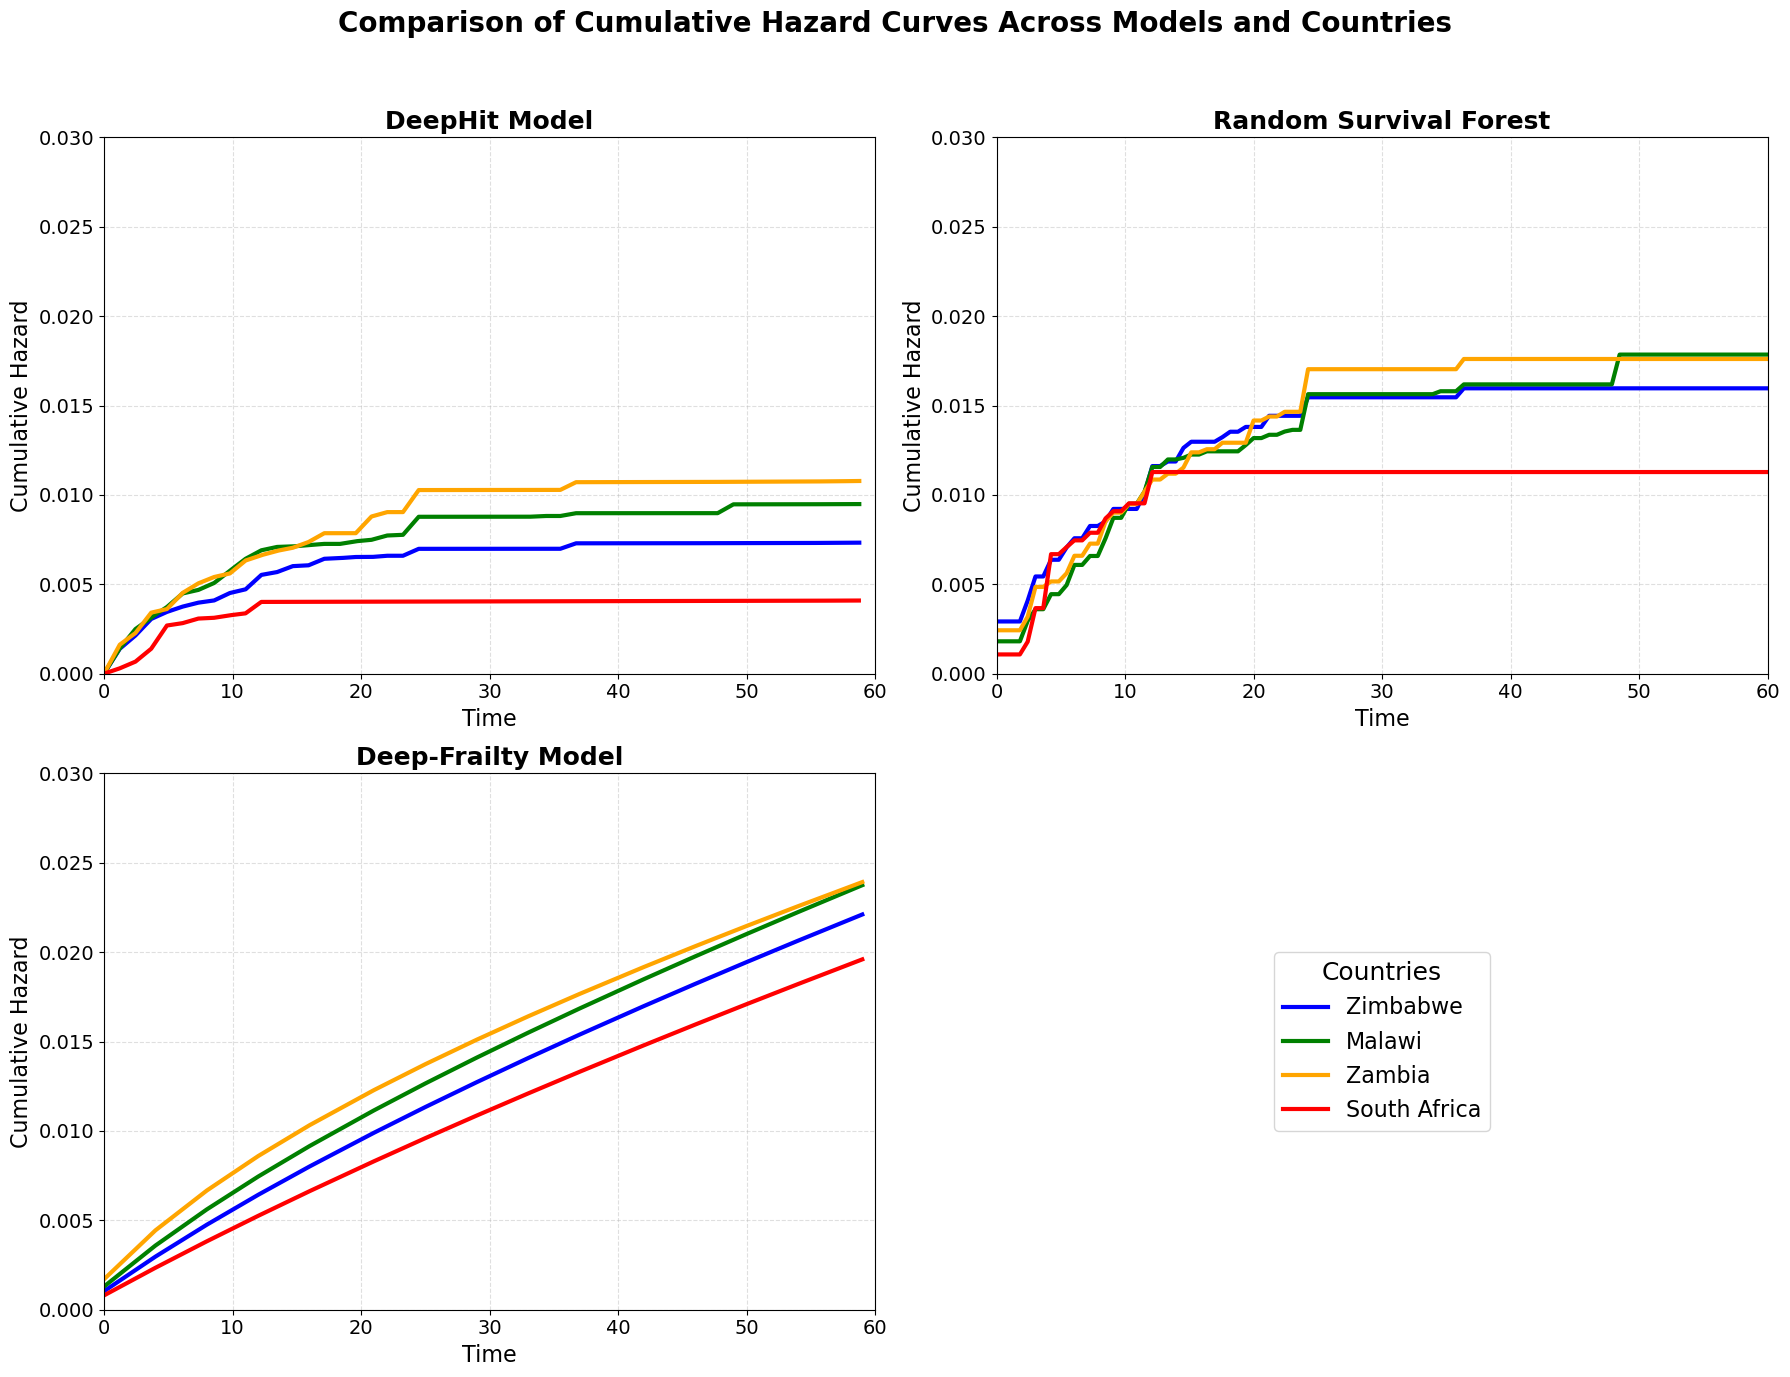

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest


country_colors = {
    'Zimbabwe': 'blue',
    'Malawi': 'green',
    'Zambia': 'orange',
    'South Africa': 'red'
}


def get_deephit_failure_curves(mean_survival_curves_dict):
    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    deephit_results = {}

    for country in countries:
        survival_data_list = mean_survival_curves_dict[country]
        concatenated_df = pd.concat(survival_data_list, axis=1)

        mean_survival_probabilities = concatenated_df.mean(axis=1)
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)

        time_data = concatenated_df.index.values
        failure_probabilities = 1 - mean_survival_probabilities

        # Apply same masking logic as your original code
        failure_probabilities = np.where(mean_survival_probabilities >= 0.97,
                                         failure_probabilities,
                                         np.nan)

        deephit_results[country] = (time_data, failure_probabilities)

    return deephit_results

def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name,
                                        n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold
        )
        rsf.fit(X_train, y_train)
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves


def get_rsf_failure_curves(surv_curves_dict):
    rsf_results = {}
    time_grid = np.linspace(0, 60, 100)

    for country, surv_curves_per_fold in surv_curves_dict.items():
        all_surv_funcs = []
        for fold in surv_curves_per_fold:
            all_surv_funcs.extend(fold)

        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(time_grid)))

        for j, fn in enumerate(all_surv_funcs):
            y_vals = fn(fn.x)
            first_val = y_vals[0]
            last_val = y_vals[-1]

            extended_vals = np.array([
                fn(t) if fn.x[0] <= t <= fn.x[-1] else
                (first_val if t < fn.x[0] else last_val)
                for t in time_grid
            ])
            surv_probs_matrix[j, :] = extended_vals

        mean_surv = surv_probs_matrix.mean(axis=0)
        mean_surv = np.minimum.accumulate(mean_surv)
        mean_failure = 1 - mean_surv

        rsf_results[country] = (time_grid, mean_failure)

    return rsf_results
def get_deepfrailty_failure_curves():
    dfZim = pd.read_csv('Zimbabwe_resultssurvivalFULL.csv')
    dfZamb = pd.read_csv('Zambia_resultssurvivalFULL.csv')
    dfSouth = pd.read_csv('SouthAfrica_resultssurvivalFULL.csv')
    dfMalawi = pd.read_csv('Malawi_resultssurvivalFULL.csv')

    mean_Zim = dfZim.mean()
    mean_Zamb = dfZamb.mean()
    mean_South = dfSouth.mean()
    mean_Malawi = dfMalawi.mean()

    fail_Zim = 1 - mean_Zim
    fail_Zamb = 1 - mean_Zamb
    fail_South = 1 - mean_South
    fail_Malawi = 1 - mean_Malawi

    time_points = np.linspace(0, 59, num=15, dtype=int)

    deepfrailty_results = {
        'Zimbabwe': (time_points, fail_Zim[time_points].values),
        'Malawi': (time_points, fail_Malawi[time_points].values),
        'Zambia': (time_points, fail_Zamb[time_points].values),
        'South Africa': (time_points, fail_South[time_points].values)
    }

    return deepfrailty_results

def plot_combined_failure_curves(deephit_results, rsf_results, deepfrailty_results):
    plt.style.use('default')

    fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor='white')
    axes = axes.flatten()

    model_results = [
        ('DeepHit Model', deephit_results),
        ('Random Survival Forest', rsf_results),
        ('Deep-Frailty Model', deepfrailty_results)
    ]
    for ax, (model_name, results_dict) in zip(axes[:3], model_results):
        for country, (time_data, failure_data) in results_dict.items():
            ax.plot(
                time_data,
                failure_data,
                color=country_colors[country],
                linewidth=3
            )

        ax.set_title(model_name, fontsize=18, weight='bold')
        ax.set_xlabel('Time', fontsize=16)
        ax.set_ylabel('Cumulative Hazard', fontsize=16)
        ax.set_xlim(0, 60)
        ax.set_ylim(0, 0.03)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(axis='both', labelsize=14)

    legend_ax = axes[3]
    legend_ax.axis('off')  
    for country, color in country_colors.items():
        legend_ax.plot([], [], color=color, linewidth=3, label=country)

    legend_ax.legend(
        loc='center',
        fontsize=16,
        frameon=True,
        title='Countries',
        title_fontsize=18
    )

    fig.suptitle(
        'Comparison of Cumulative Hazard Curves Across Models and Countries',
        fontsize=20,
        weight='bold'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

deephit_results = get_deephit_failure_curves(mean_survival_curves_dict_deephit)

surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}
rsf_results = get_rsf_failure_curves(surv_curves_dict_rsf)

deepfrailty_results = get_deepfrailty_failure_curves()

plot_combined_failure_curves(deephit_results, rsf_results, deepfrailty_results)

In [74]:
from IPython.display import FileLink
import matplotlib.pyplot as plt

def plot_combined_failure_curves(deephit_results, rsf_results, deepfrailty_results):

    plt.style.use('default')

    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 12),
        facecolor='white'
    )

    axes = axes.flatten()

    model_results = [
        ('DeepHit Model', deephit_results),
        ('Random Survival Forest', rsf_results),
        ('Deep-Frailty Model', deepfrailty_results)
    ]

    for ax, (model_name, results_dict) in zip(axes[:3], model_results):

        for country, (time_data, failure_data) in results_dict.items():

            ax.plot(
                time_data,
                failure_data,
                color=country_colors[country],
                linewidth=3,
                label=country
            )

        ax.set_title(
            model_name,
            fontsize=18,
            weight='bold',
            pad=12
        )

        ax.set_xlabel('Time', fontsize=15)
        ax.set_ylabel('Cumulative Hazard Curves', fontsize=15)

        ax.set_xlim(0, 60)
        ax.set_ylim(0, 0.03)

        ax.grid(True, linestyle='--', alpha=0.35)
        ax.tick_params(axis='both', labelsize=13)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    legend_ax = axes[3]
    legend_ax.axis('off')

    handles = []

    for country, color in country_colors.items():

        line, = legend_ax.plot(
            [],
            [],
            color=color,
            linewidth=4,
            label=country
        )

        handles.append(line)

    legend_ax.legend(
        handles=handles,
        loc='center',
        fontsize=15,
        frameon=True,
        title='Countries',
        title_fontsize=17,
        edgecolor='black'
    )

    fig.suptitle(
        'Comparison of Cumulative Hazard Curves Across Models and Countries',
        fontsize=22,
        weight='bold',
        y=0.98
    )

    fig.subplots_adjust(
        top=0.90,
        bottom=0.08,
        left=0.08,
        right=0.97,
        hspace=0.28,
        wspace=0.20
    )

    fig.savefig(
        "Combined_Cumulative_Incidence_Curves.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        "Combined_Cumulative_Incidence_Curves.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    return FileLink("Combined_Cumulative_Incidence_Curves.pdf")

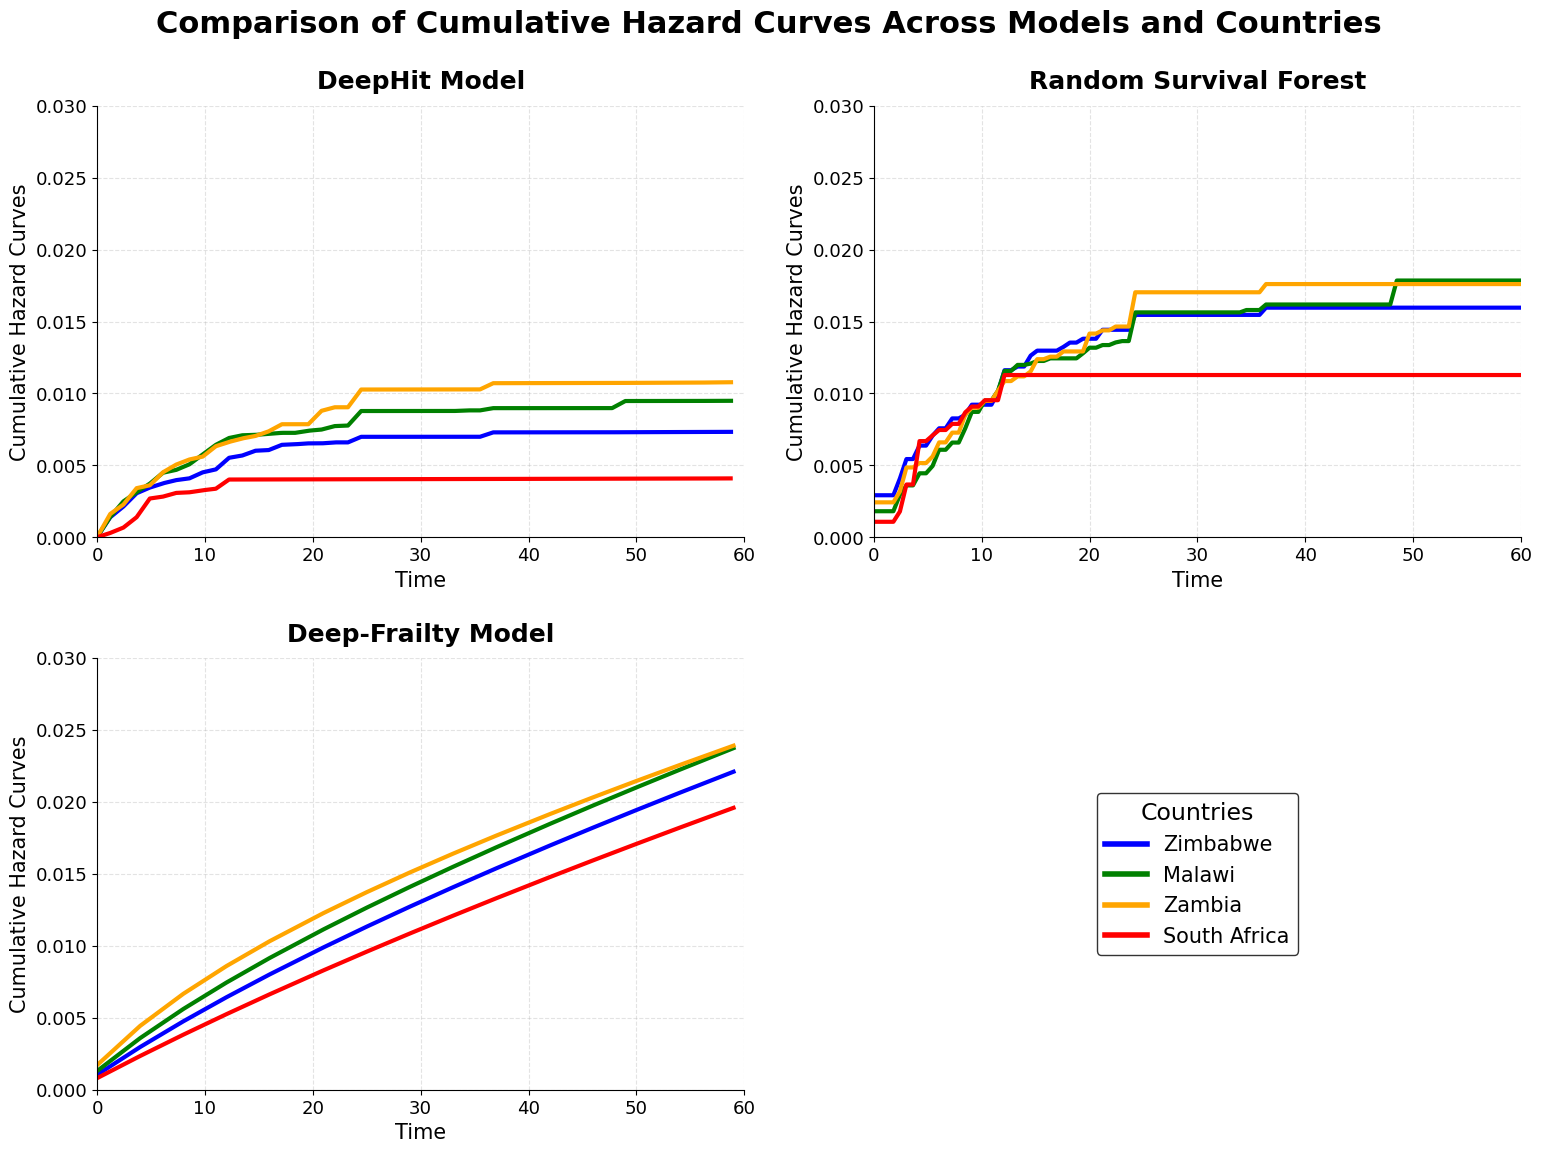

/home/justine/Combined_Cumulative_Incidence_Curves.pdf

In [75]:
plot_combined_failure_curves(
    deephit_results,
    rsf_results,
    deepfrailty_results
)

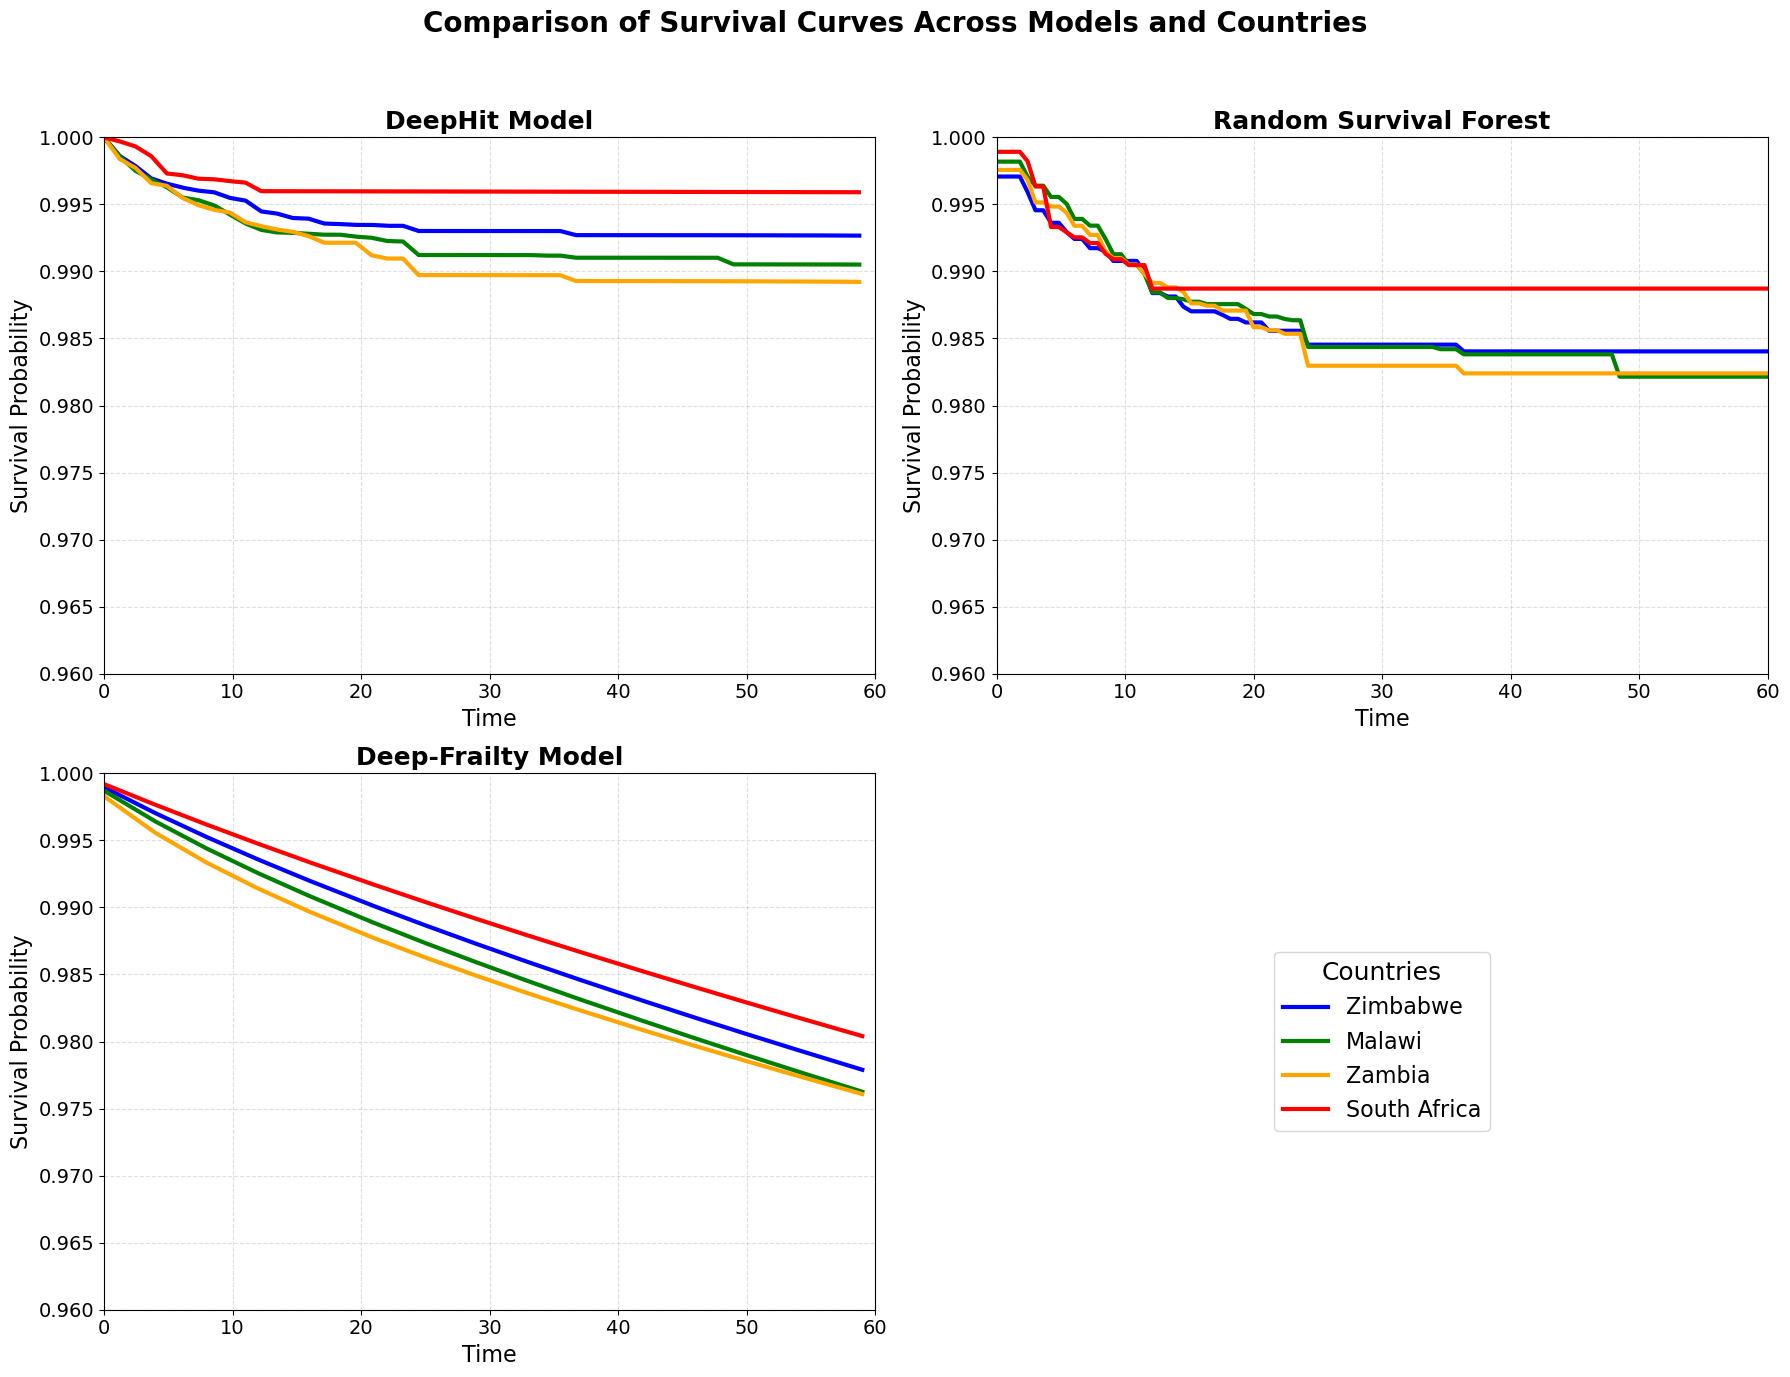

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest


country_colors = {
    'Zimbabwe': 'blue',
    'Malawi': 'green',
    'Zambia': 'orange',
    'South Africa': 'red'
}

def get_deephit_survival_curves(mean_survival_curves_dict):
    countries = ['Zimbabwe', 'Malawi', 'Zambia', 'South Africa']
    deephit_results = {}

    for country in countries:
        survival_data_list = mean_survival_curves_dict[country]
        concatenated_df = pd.concat(survival_data_list, axis=1)

        mean_survival_probabilities = concatenated_df.mean(axis=1)
        mean_survival_probabilities = np.minimum.accumulate(mean_survival_probabilities)

        time_data = concatenated_df.index.values

        # Apply same masking logic as your original code
        mean_survival_probabilities = np.where(mean_survival_probabilities >= 0.97,
                                               mean_survival_probabilities,
                                               np.nan)

        deephit_results[country] = (time_data, mean_survival_probabilities)

    return deephit_results

def fit_rsf_and_collect_survival_curves(df, duration_col, event_col, dataset_name,
                                        n_estimators=100, folds=5):
    X = df.drop(columns=[duration_col, event_col])
    y = np.array([(bool(row[event_col]), row[duration_col]) for _, row in df.iterrows()],
                 dtype=[('event', 'bool'), ('time', 'float')])

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    surv_curves = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_estimators,
            min_samples_split=10,
            min_samples_leaf=15,
            max_features="sqrt",
            n_jobs=-1,
            random_state=fold
        )
        rsf.fit(X_train, y_train)
        surv_prob = rsf.predict_survival_function(X_val)
        surv_curves.append(surv_prob)

    return surv_curves


def get_rsf_survival_curves(surv_curves_dict):
    rsf_results = {}
    time_grid = np.linspace(0, 60, 100)

    for country, surv_curves_per_fold in surv_curves_dict.items():
        all_surv_funcs = []
        for fold in surv_curves_per_fold:
            all_surv_funcs.extend(fold)

        surv_probs_matrix = np.zeros((len(all_surv_funcs), len(time_grid)))

        for j, fn in enumerate(all_surv_funcs):
            y_vals = fn(fn.x)
            first_val = y_vals[0]
            last_val = y_vals[-1]

            extended_vals = np.array([
                fn(t) if fn.x[0] <= t <= fn.x[-1] else
                (first_val if t < fn.x[0] else last_val)
                for t in time_grid
            ])
            surv_probs_matrix[j, :] = extended_vals

        mean_surv = surv_probs_matrix.mean(axis=0)
        mean_surv = np.minimum.accumulate(mean_surv)

        rsf_results[country] = (time_grid, mean_surv)

    return rsf_results


def get_deepfrailty_survival_curves():
    dfZim = pd.read_csv('Zimbabwe_resultssurvivalFULL.csv')
    dfZamb = pd.read_csv('Zambia_resultssurvivalFULL.csv')
    dfSouth = pd.read_csv('SouthAfrica_resultssurvivalFULL.csv')
    dfMalawi = pd.read_csv('Malawi_resultssurvivalFULL.csv')

    mean_Zim = dfZim.mean()
    mean_Zamb = dfZamb.mean()
    mean_South = dfSouth.mean()
    mean_Malawi = dfMalawi.mean()

    time_points = np.linspace(0, 59, num=15, dtype=int)

    deepfrailty_results = {
        'Zimbabwe': (time_points, mean_Zim[time_points].values),
        'Malawi': (time_points, mean_Malawi[time_points].values),
        'Zambia': (time_points, mean_Zamb[time_points].values),
        'South Africa': (time_points, mean_South[time_points].values)
    }

    return deepfrailty_results
def plot_combined_survival_curves(deephit_results, rsf_results, deepfrailty_results):
    plt.style.use('default')

    fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor='white')
    axes = axes.flatten()

    model_results = [
        ('DeepHit Model', deephit_results),
        ('Random Survival Forest', rsf_results),
        ('Deep-Frailty Model', deepfrailty_results)
    ]
    for ax, (model_name, results_dict) in zip(axes[:3], model_results):
        for country, (time_data, survival_data) in results_dict.items():
            ax.plot(
                time_data,
                survival_data,
                color=country_colors[country],
                linewidth=3
            )

        ax.set_title(model_name, fontsize=18, weight='bold')
        ax.set_xlabel('Time', fontsize=16)
        ax.set_ylabel('Survival Probability', fontsize=16)
        ax.set_xlim(0, 60)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(axis='both', labelsize=14)
        ax.set_ylim(0.96, 1.0)
    legend_ax = axes[3]
    legend_ax.axis('off')

    for country, color in country_colors.items():
        legend_ax.plot([], [], color=color, linewidth=3, label=country)

    legend_ax.legend(
        loc='center',
        fontsize=16,
        frameon=True,
        title='Countries',
        title_fontsize=18
    )

    fig.suptitle(
        'Comparison of Survival Curves Across Models and Countries',
        fontsize=20,
        weight='bold'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

deephit_results = get_deephit_survival_curves(mean_survival_curves_dict_deephit)

surv_curves_dict_rsf = {
    'Zimbabwe': fit_rsf_and_collect_survival_curves(zimbabwe_selected_df, 'survival_time', 'Status_1', 'Zimbabwe'),
    'Malawi': fit_rsf_and_collect_survival_curves(malawi_selected_df, 'survival_time', 'Status_1', 'Malawi'),
    'Zambia': fit_rsf_and_collect_survival_curves(zambia_selected_df, 'survival_time', 'Status_1', 'Zambia'),
    'South Africa': fit_rsf_and_collect_survival_curves(sa_selected_df, 'survival_time', 'Status_1', 'South Africa')
}
rsf_results = get_rsf_survival_curves(surv_curves_dict_rsf)

deepfrailty_results = get_deepfrailty_survival_curves()

plot_combined_survival_curves(deephit_results, rsf_results, deepfrailty_results)

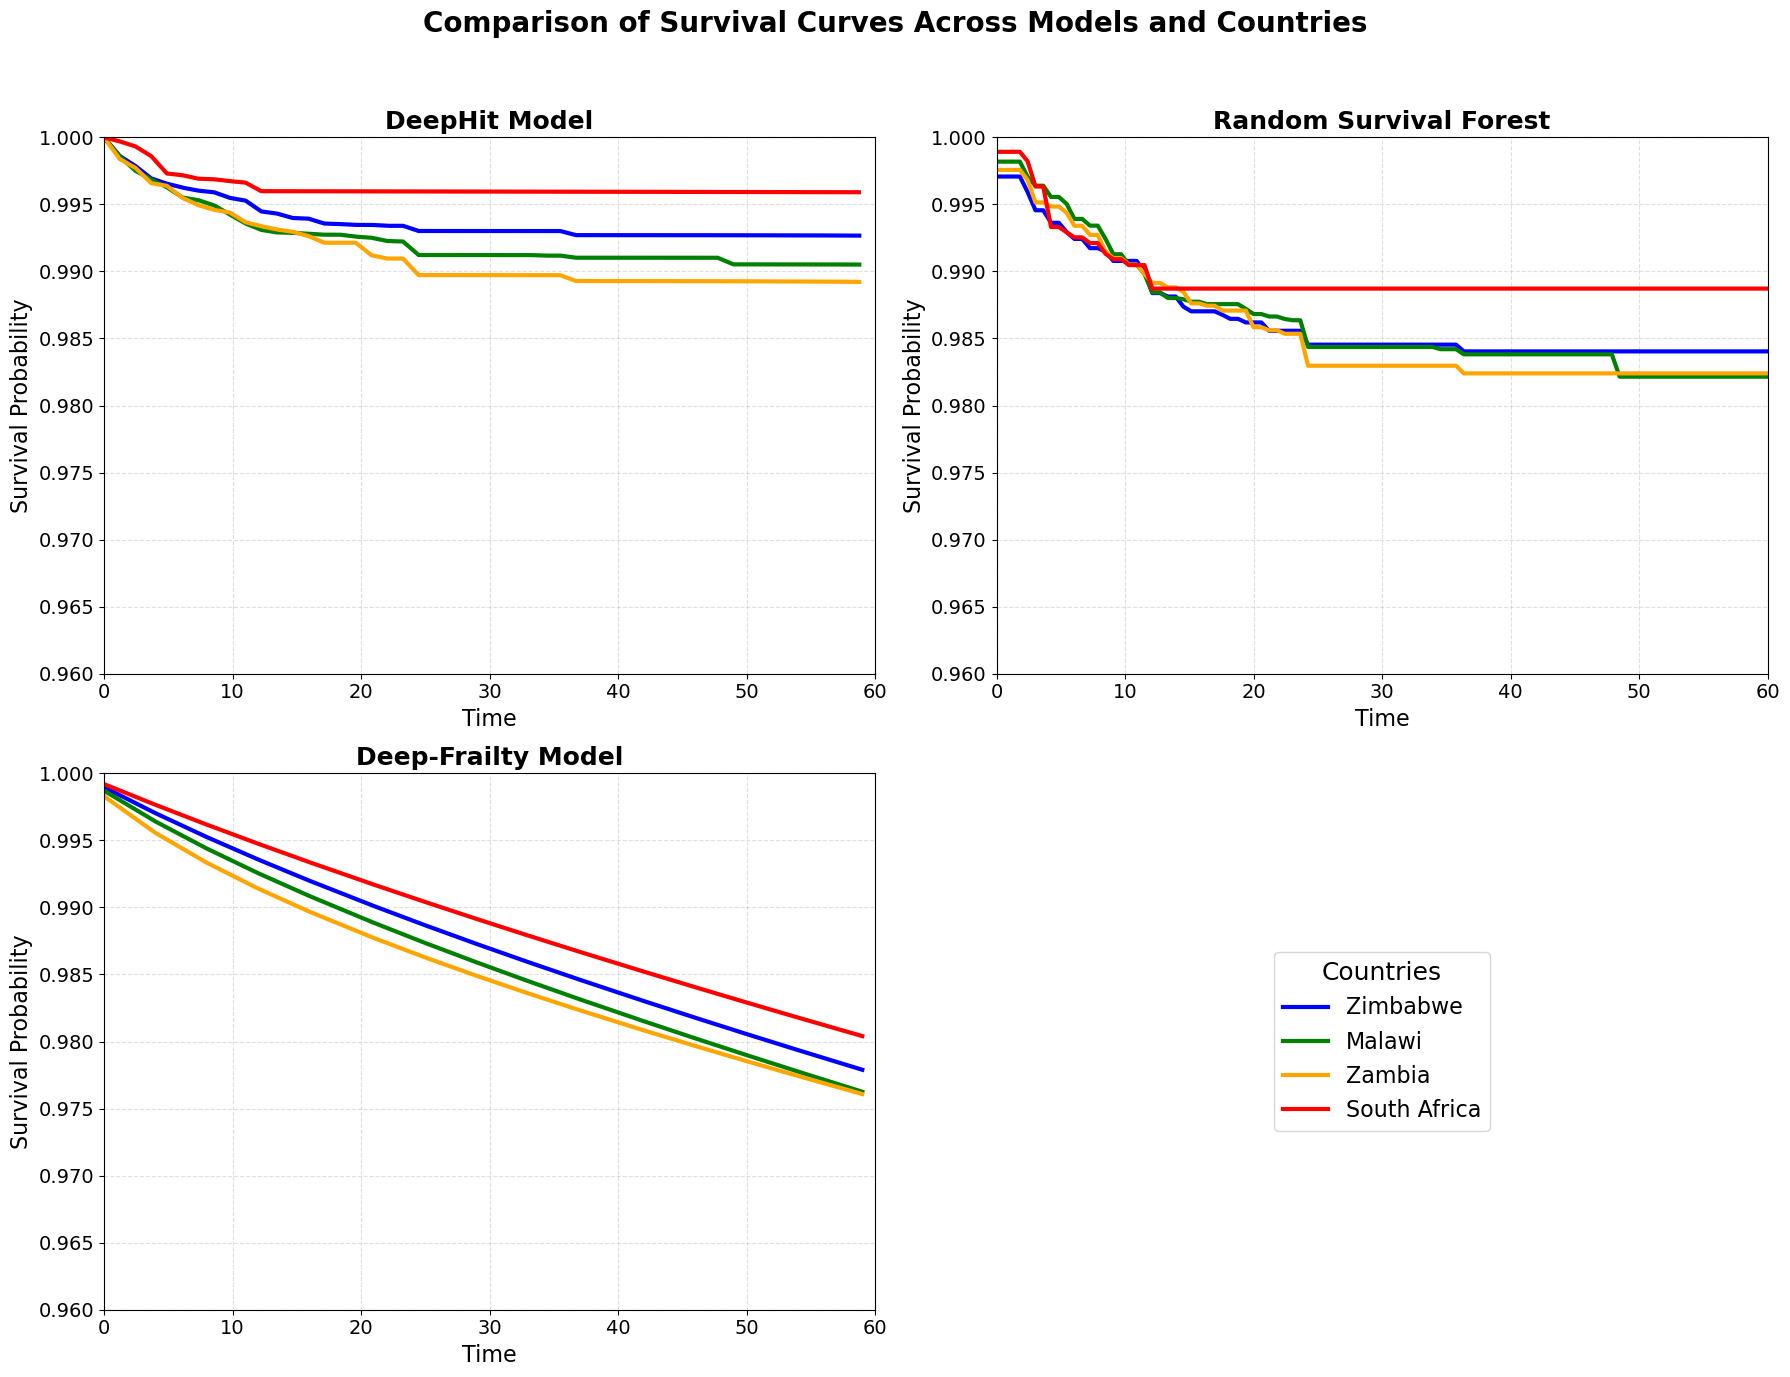

In [66]:
plot_combined_survival_curves(
    deephit_results,
    rsf_results,
    deepfrailty_results
)

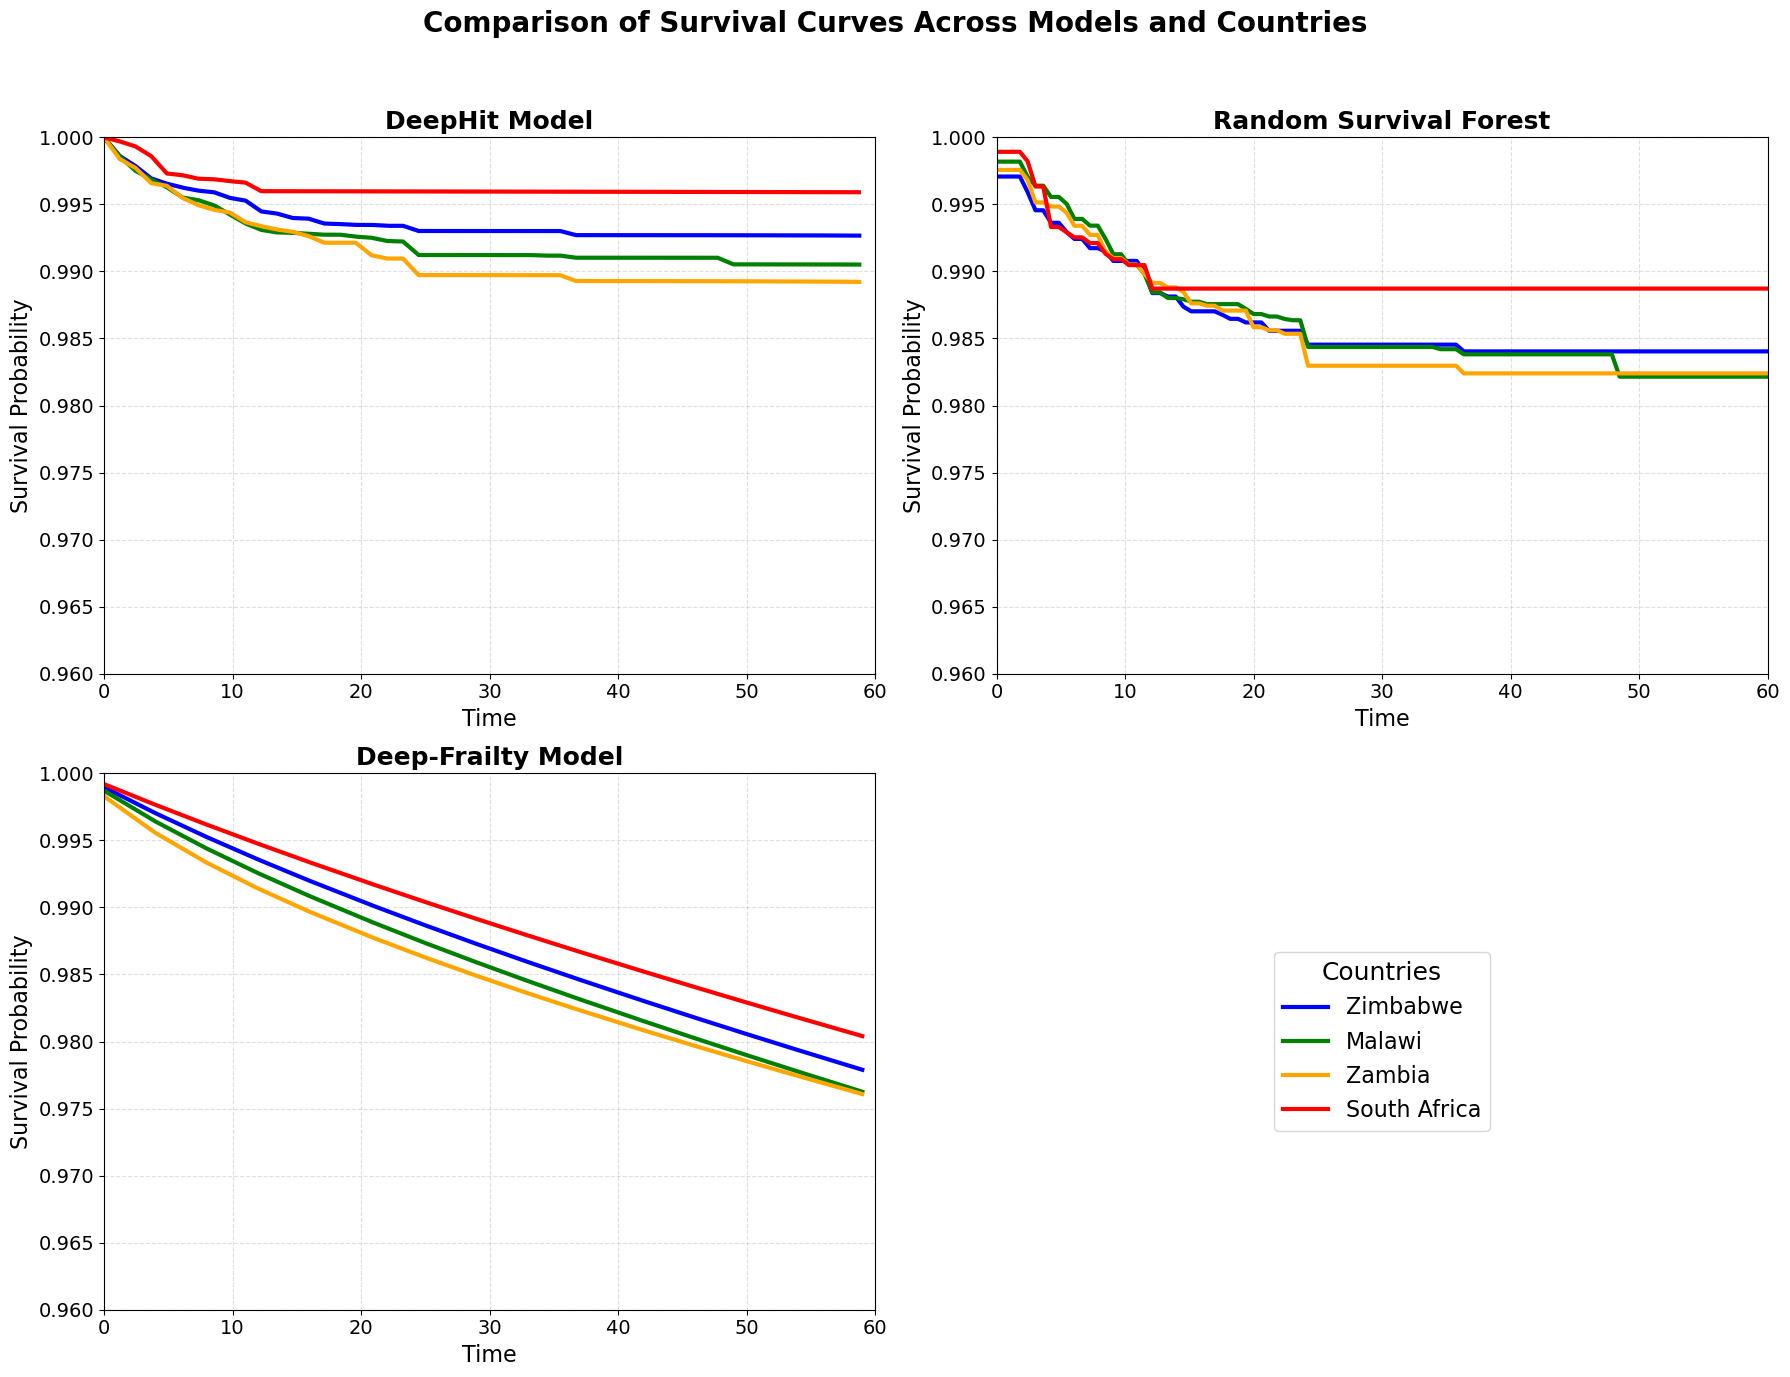

/home/justine/Combined_Survival_Curves_Comparison.pdf

In [67]:
from IPython.display import FileLink

plot_combined_survival_curves(
    deephit_results,
    rsf_results,
    deepfrailty_results
)

FileLink("Combined_Survival_Curves_Comparison.pdf")

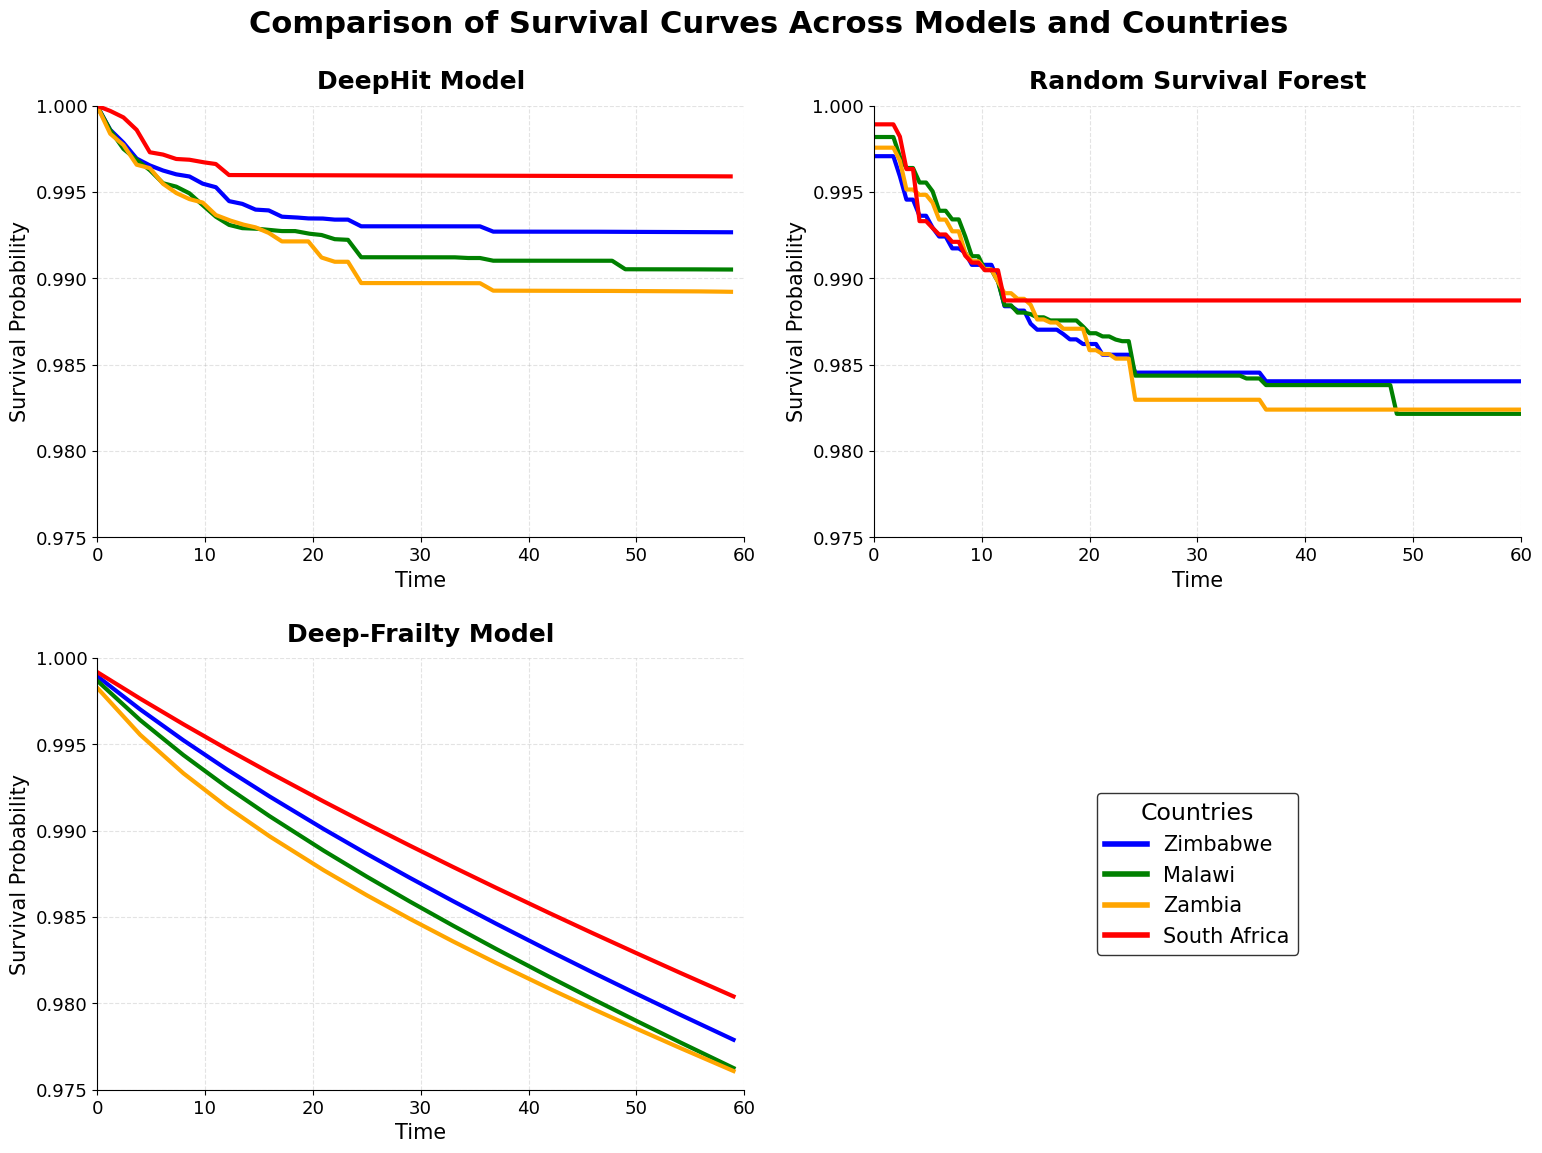

/home/justine/Combined_Survival_Curves_Comparison.pdf

In [70]:
from IPython.display import FileLink
import matplotlib.pyplot as plt

def plot_combined_survival_curves(deephit_results, rsf_results, deepfrailty_results):

    plt.style.use('default')

    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 12),
        facecolor='white'
    )

    axes = axes.flatten()

    model_results = [
        ('DeepHit Model', deephit_results),
        ('Random Survival Forest', rsf_results),
        ('Deep-Frailty Model', deepfrailty_results)
    ]
    for ax, (model_name, results_dict) in zip(axes[:3], model_results):

        for country, (time_data, survival_data) in results_dict.items():

            ax.plot(
                time_data,
                survival_data,
                color=country_colors[country],
                linewidth=3,
                label=country
            )

        ax.set_title(
            model_name,
            fontsize=18,
            weight='bold',
            pad=12
        )

        ax.set_xlabel('Time', fontsize=15)
        ax.set_ylabel('Survival Probability', fontsize=15)

        ax.set_xlim(0, 60)
        ax.set_ylim(0.975, 1.0)

        ax.grid(True, linestyle='--', alpha=0.35)

        ax.tick_params(axis='both', labelsize=13)

        # Cleaner axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    legend_ax = axes[3]
    legend_ax.axis('off')

    handles = []

    for country, color in country_colors.items():

        line, = legend_ax.plot(
            [],
            [],
            color=color,
            linewidth=4,
            label=country
        )

        handles.append(line)

    legend_ax.legend(
        handles=handles,
        loc='center',
        fontsize=15,
        frameon=True,
        title='Countries',
        title_fontsize=17,
        edgecolor='black'
    )
    fig.suptitle(
        'Comparison of Survival Curves Across Models and Countries',
        fontsize=22,
        weight='bold',
        y=0.98
    )
    fig.subplots_adjust(
        top=0.90,
        bottom=0.08,
        left=0.08,
        right=0.97,
        hspace=0.28,
        wspace=0.20
    )
    fig.savefig(
        "Combined_Survival_Curves_Comparison.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        "Combined_Survival_Curves_Comparison.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    return FileLink("Combined_Survival_Curves_Comparison.pdf")
plot_combined_survival_curves(
    deephit_results,
    rsf_results,
    deepfrailty_results
)

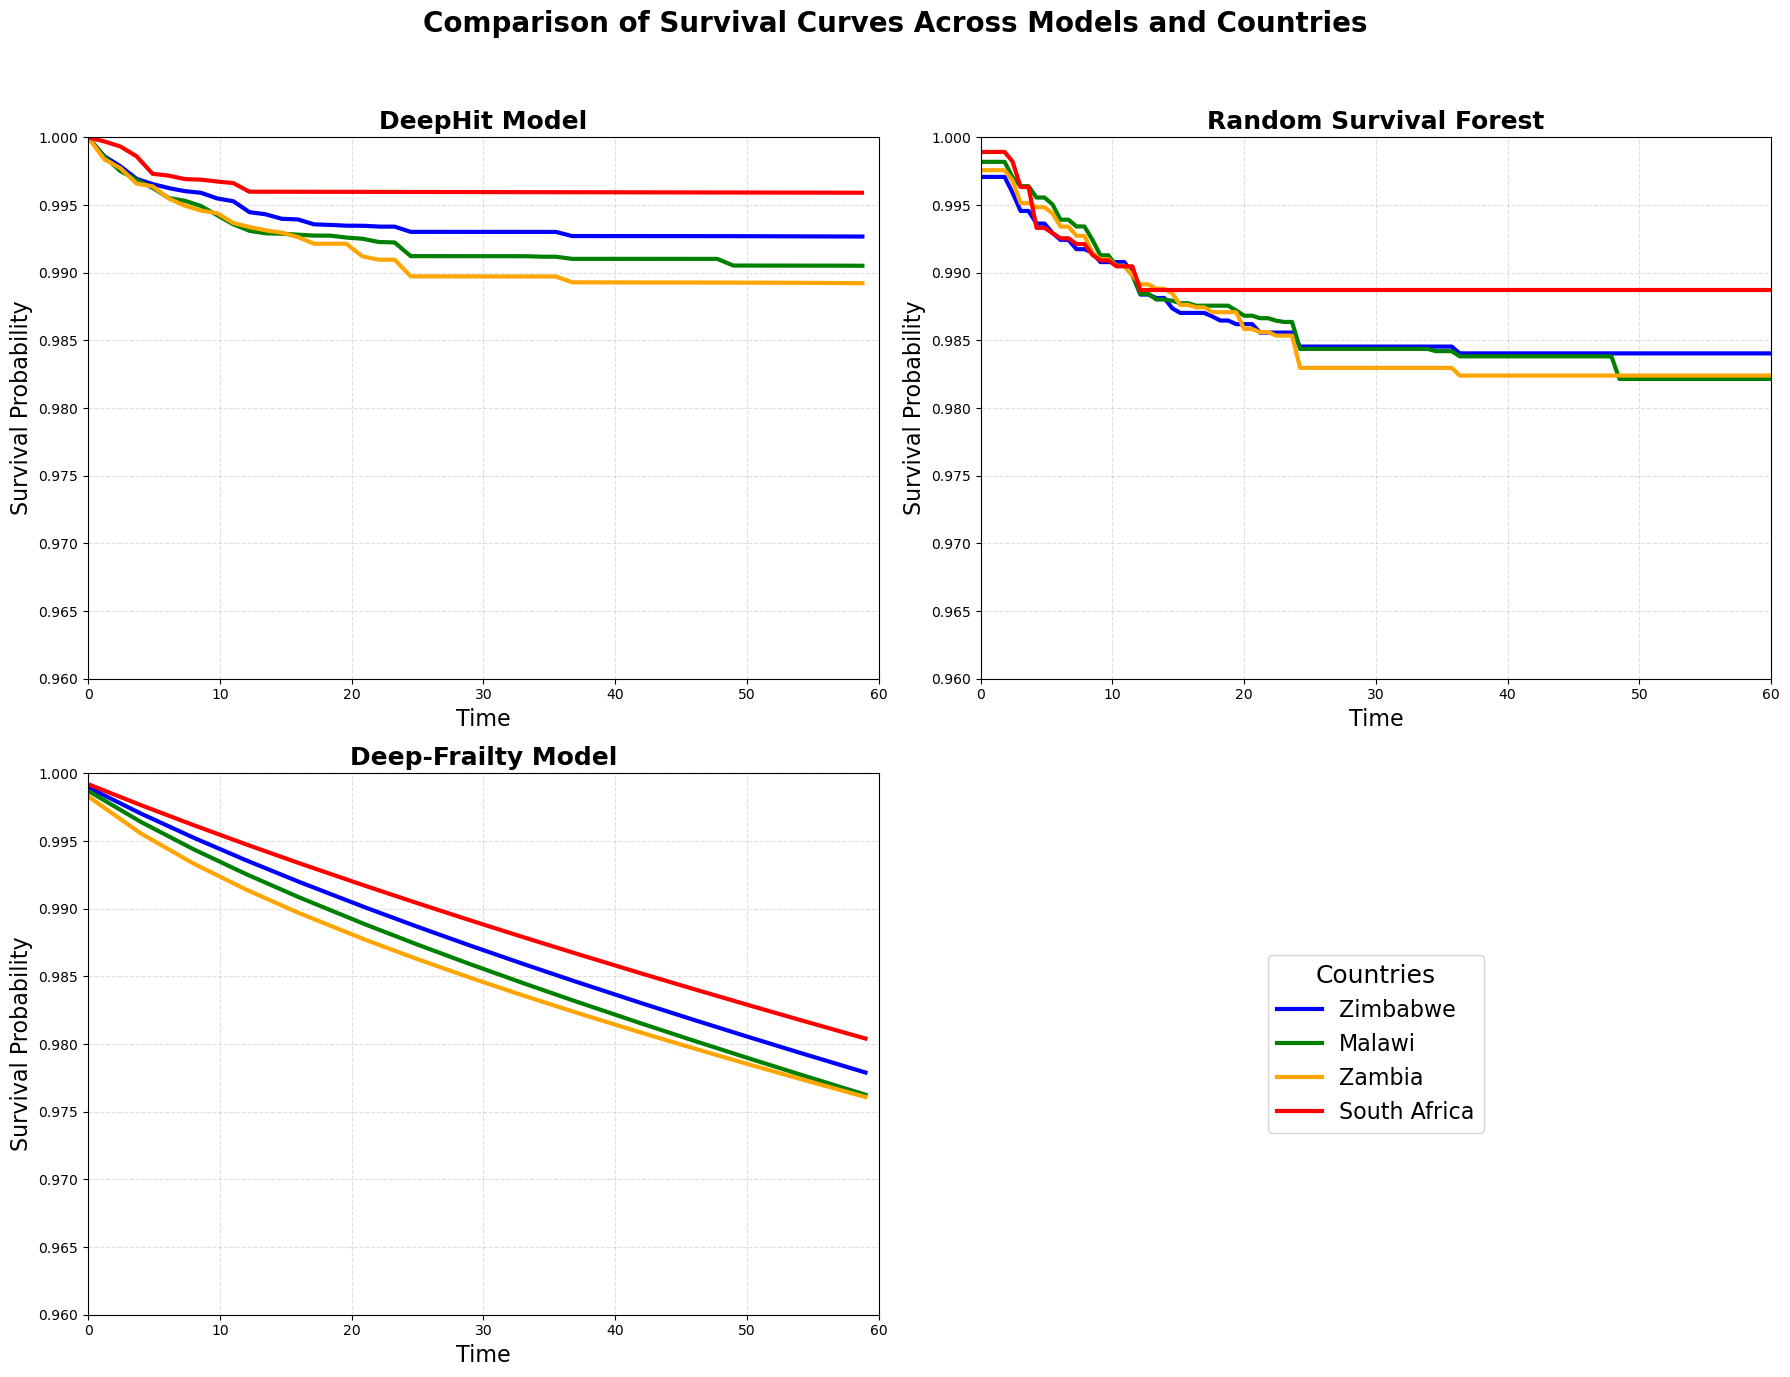

/home/justine/Combined_Survival_Curves_Comparison.pdf

In [69]:
plot_combined_survival_curves(
    deephit_results,
    rsf_results,
    deepfrailty_results
)